<a href="https://colab.research.google.com/github/patoblua/Diplomatura-UTN/blob/main/Proyecto_Final_Grupo_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Calidad del Aire (AQI) — Delhi
## Diplomado en Ciencia de Datos y Análisis Avanzado — Proyecto Final Integrador

### Estrategia de modelado

#### Hipótesis inicial
Se diseño una estrategia sobre el siguente eje:

| Hipótesis | Eje | Pregunta |
|-----------|-----|----------|
| **H1** | Opción 1 — Patrón espacial | ¿Los modelos locales superan al modelo global? |
| **H2** | Opción 3 — Metodología | ¿El LSTM supera a los modelos clásicos en el modelo global? |

El EDA reveló que las 6 estaciones se agrupan en **2 perfiles estadísticamente idénticos**,
lo que invalida el enfoque por estación. La estrategia se rediseñó sobre dos ejes:

| Hipótesis | Eje | Pregunta |
|-----------|-----|----------|
| **H1** |  Régimen | ¿Los modelos por régimen superan al modelo global? |
| **H2a** | Metodología | ¿El LSTM con lags supera a los modelos clásicos? |
| **H2b** | Metodología | ¿El LSTM sin lags  supera a los modelos clásicos? |
| **H3** | LSTM interno | ¿El LSTM con lags supera al LSTM sin lags? |
| **H4** | Régimen LSTM | ¿El LSTM se comporta distinto en régimen crítico vs. normal? |

### Estructura
1. Configuración e instalación
2. Carga y EDA
3. Hallazgo: duplicación de estaciones
4. Selección de estaciones representativas
5. Preprocesamiento y feature engineering
6. Segmentación por régimen
7. Funciones auxiliares
8. **ETAPA 1 — Clasificación** (4 modelos × 3 segmentos)
9. **ETAPA 2 — Regresión clásica** (4 modelos × 3 segmentos)
10. **ETAPA 3 — LSTM** (con lags / sin lags × 3 segmentos)
11. **Comparación final** y validación de hipótesis

---
> **Metodología:** CRISP-DM | **Dataset:** Kaggle

https://www.kaggle.com/datasets/sohails07/delhi-weather-and-aqi-dataset-2025



## 1. Configuración e instalación

In [ ]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
    classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier, XGBRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Parámetros globales —
DATASET_PATH     = '/content/delhi-weather-aqi-2025.csv'   # cargar en Archivos
STATION_COL      = 'location'         #  columna de estación
DATE_COL         = 'date_ist'         #  columna de fecha
TIME_COL         = 'time_ist'         #  columna de hora
DATETIME_COL     = 'datetime'         #  columna combinada
TARGET_REG       = 'aqi_index'        #  valor numérico del AQI
TARGET_CLF       = 'AQI_category'     #  categoría
TEST_SIZE        = 0.2
REGIME_THRESHOLD = 150                #  umbral normal/crítico (escala EPA)
N_STEPS          = 24                 #  ventana temporal para LSTM

GRUPO_A = ['Anand Vihar', 'Connaught Place', 'Rohini']
GRUPO_B = ['Dwarka', 'IGI Airport', 'Okhla Phase III']

# Estación representativa por grupo (primera de cada lista)
REP_A = GRUPO_A[0]
REP_B = GRUPO_B[0]

print('✓ Librerías importadas')
print(f'  TensorFlow {tf.__version__}')
print(f'  Estación representativa Grupo A: {REP_A}')
print(f'  Estación representativa Grupo B: {REP_B}')

✓ Librerías importadas
  TensorFlow 2.19.0
  Estación representativa Grupo A: Anand Vihar
  Estación representativa Grupo B: Dwarka


## 2. Carga y EDA

In [ ]:
df_raw = pd.read_csv(DATASET_PATH)

# Crear columna datetime desde date_ist + time_ist
df_raw[DATETIME_COL] = pd.to_datetime(
    df_raw[DATE_COL] + ' ' + df_raw[TIME_COL],
    format='%d/%m/%Y %H:%M'
)
df_raw = df_raw.sort_values([STATION_COL, DATETIME_COL]).reset_index(drop=True)

print(f'Dataset completo — Filas: {df_raw.shape[0]:,}  |  Columnas: {df_raw.shape[1]}')
print(f'Rango temporal: {df_raw[DATETIME_COL].min()} → {df_raw[DATETIME_COL].max()}')
df_raw.head()

Dataset completo — Filas: 52,560  |  Columnas: 17
Rango temporal: 2025-01-01 00:00:00 → 2025-12-31 23:00:00


,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2,datetime
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7,2025-01-01 00:00:00
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8,2025-01-01 01:00:00
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6,2025-01-01 02:00:00
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7,2025-01-01 03:00:00
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6,2025-01-01 04:00:00


In [ ]:
print('── Tipos de datos ─────────────────────────────────')
print(df_raw.dtypes)
print()
print('── Nulos (%) ──────────────────────────────────────')
nulls = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)
print(nulls[nulls > 0])

── Tipos de datos ─────────────────────────────────
date_ist                  object
time_ist                  object
location                  object
lat                      float64
lon                      float64
temp_c                   float64
humidity                   int64
pressure_mb              float64
windspeed_kph            float64
condition_text            object
description               object
aqi_index                  int64
pm2_5                    float64
pm10                     float64
co                         int64
no2                      float64
datetime          datetime64[ns]
dtype: object

── Nulos (%) ──────────────────────────────────────
Series([], dtype: float64)


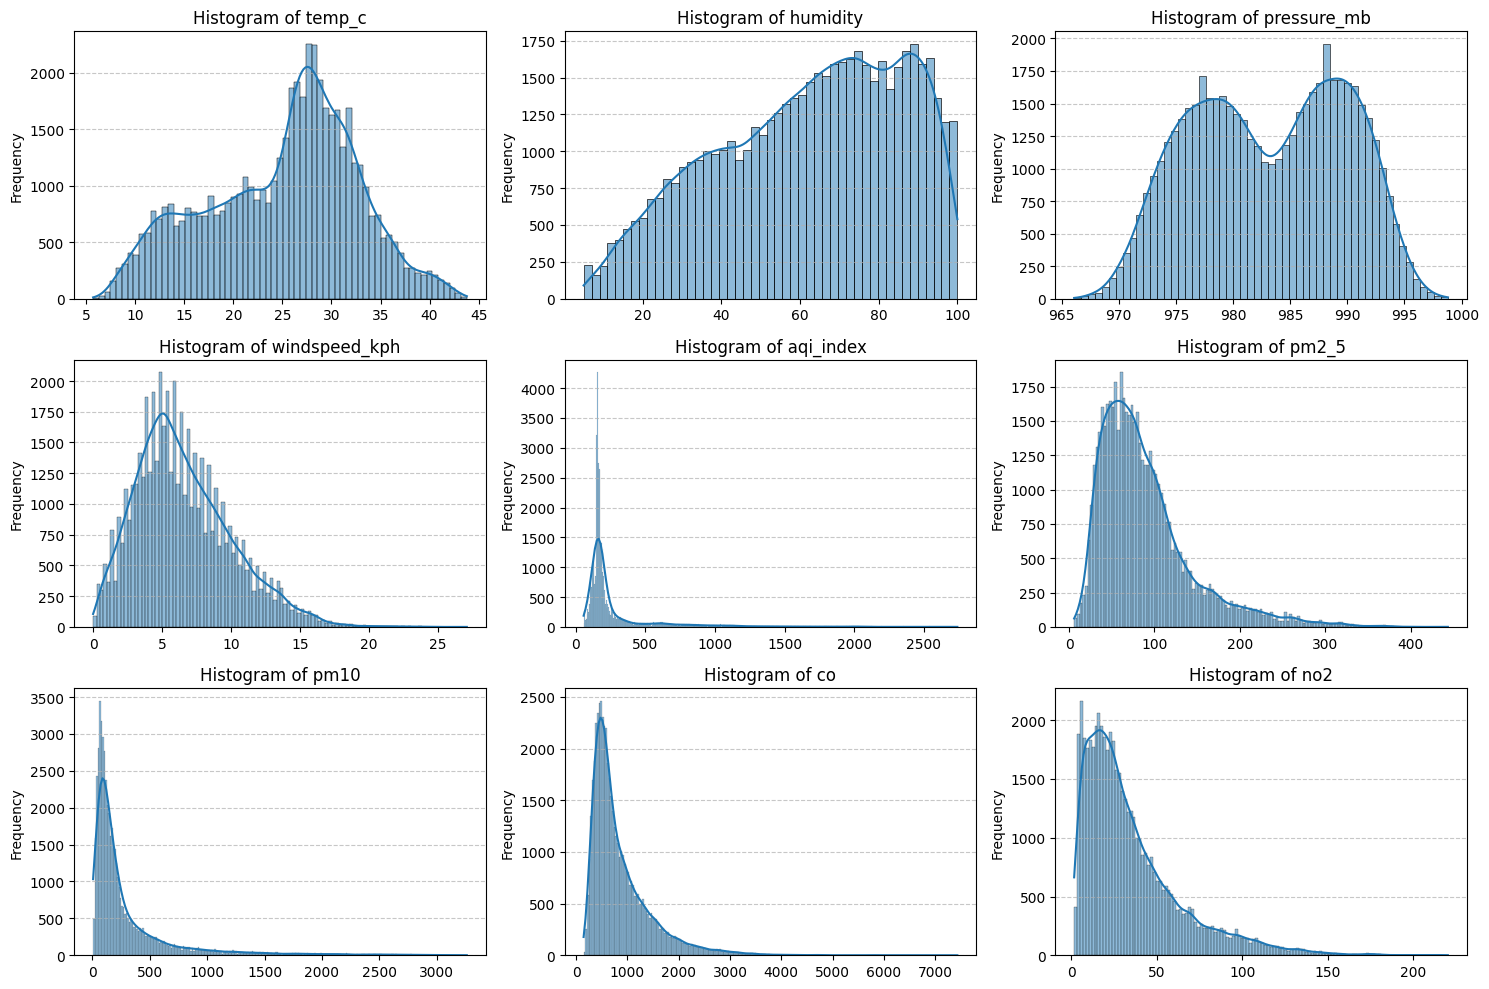

In [ ]:
variables_for_histograms = ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2']

plt.figure(figsize=(15, 10))

for i, col in enumerate(variables_for_histograms):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_raw[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

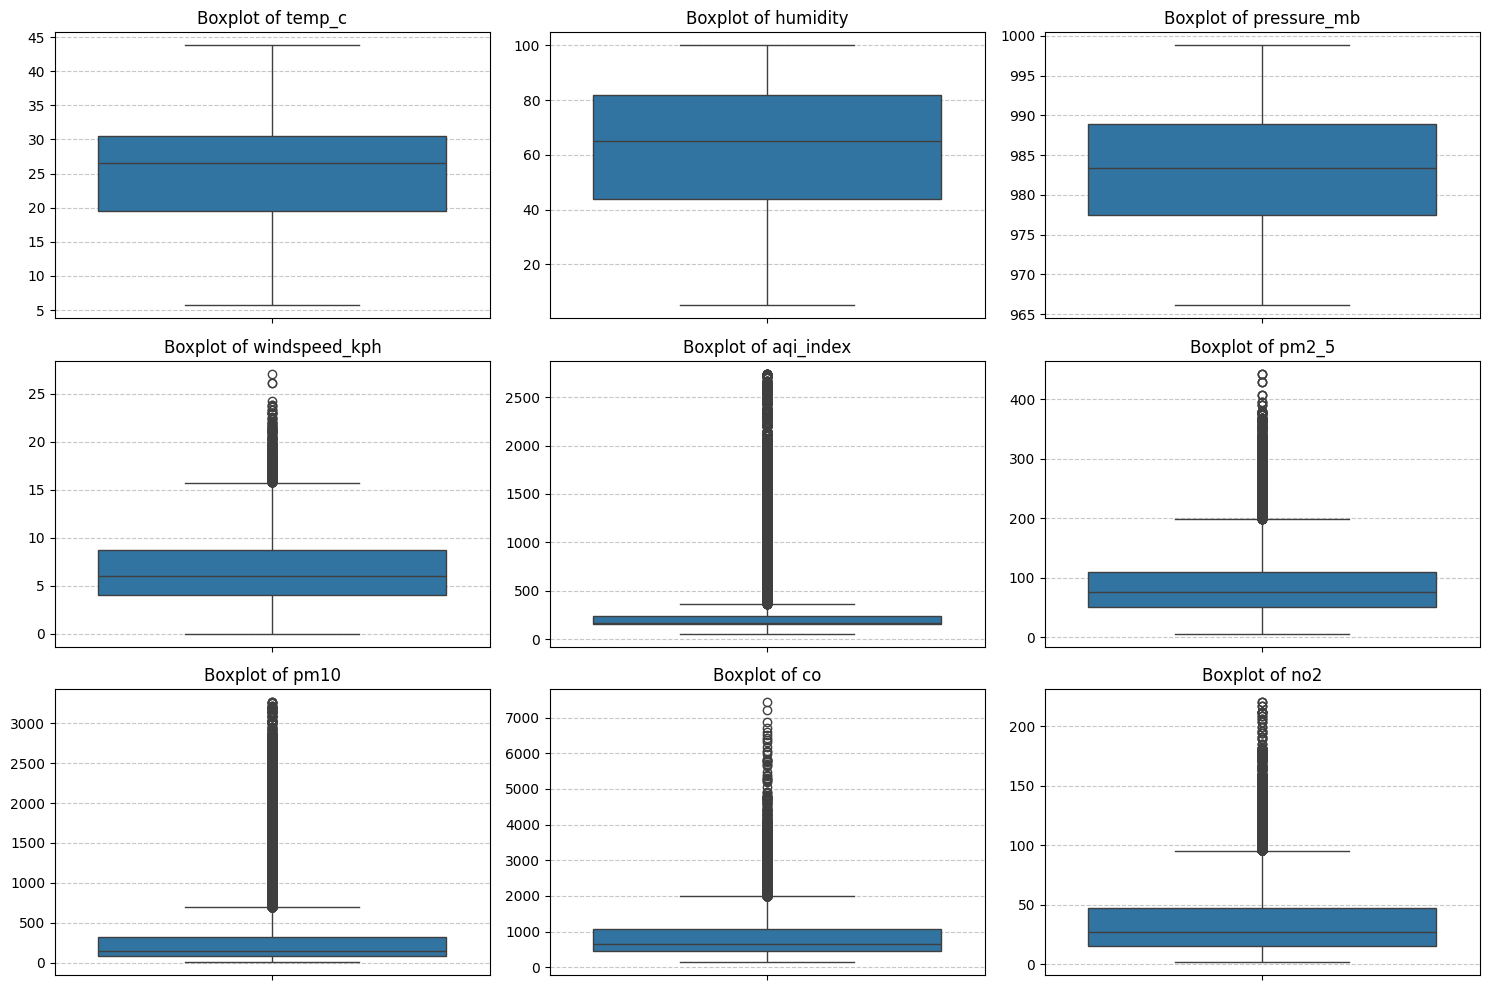

In [ ]:
variables_for_boxplots = ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2']

plt.figure(figsize=(15, 10))

for i, col in enumerate(variables_for_boxplots):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_raw[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df_raw['pm10'].quantile(0.25)
Q3 = df_raw['pm10'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_pm10 = df_raw[df_raw['pm10'] > 800]
print(f"Número de outliers en 'pm10' (valores > 800): {len(outliers_pm10)}")
print("pm10 > 800 puede ser un error de medición")
print("En situaciones extremas (especialmente tras el festival de Diwali o incendios de cultivos), plataformas como IQAir han registrado índices que han superado los 1000 puntos en áreas específicas de la ciudad.")

Número de outliers en 'pm10' (valores > 800): 4614
pm10 > 800 puede ser un error de medición
En situaciones extremas (especialmente tras el festival de Diwali o incendios de cultivos), plataformas como IQAir han registrado índices que han superado los 1000 puntos en áreas específicas de la ciudad.


In [ ]:
Q1 = df_raw['aqi_index'].quantile(0.25)
Q3 = df_raw['aqi_index'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_aqi = df_raw[df_raw['aqi_index'] > 500]

print(f"Número de outliers en 'aqi_index' (valores > 500): {len(outliers_aqi)}")
print("Valores de outliers (primeras 10 filas si hay muchos):")
display(outliers_aqi[['date_ist', 'time_ist', 'aqi_index']].head(10))

Número de outliers en 'aqi_index' (valores > 500): 6903
Valores de outliers (primeras 10 filas si hay muchos):


,date_ist,time_ist,aqi_index
1524,05/03/2025,12:00,513
1525,05/03/2025,13:00,537
1526,05/03/2025,14:00,569
1527,05/03/2025,15:00,608
1528,05/03/2025,16:00,652
1529,05/03/2025,17:00,695
1530,05/03/2025,18:00,730
1531,05/03/2025,19:00,761
1532,05/03/2025,20:00,784
1533,05/03/2025,21:00,801


In [ ]:
print("Distribución de fechas para los outliers de 'aqi_index' (> 500):")
display(outliers_aqi['date_ist'].value_counts().head(10))

Distribución de fechas para los outliers de 'aqi_index' (> 500):


,count
date_ist,
29/03/2025,144
30/03/2025,144
23/05/2025,144
10/06/2025,144
08/08/2025,144
06/03/2025,138
09/06/2025,135
11/06/2025,129
20/04/2025,129


In [ ]:
print('── Estadísticas por estación ──────────────────────')
df_raw.groupby(STATION_COL)[TARGET_REG].describe().round(2)

── Estadísticas por estación ──────────────────────


,count,mean,std,min,25%,50%,75%,max
location,,,,,,,,
Anand Vihar,8760.0,194.45,103.59,61.0,150.0,165.0,199.0,830.0
Connaught Place,8760.0,194.45,103.59,61.0,150.0,165.0,199.0,830.0
Dwarka,8760.0,380.28,432.63,56.0,153.0,178.0,424.0,2742.0
IGI Airport,8760.0,380.28,432.63,56.0,153.0,178.0,424.0,2742.0
Okhla Phase III,8760.0,380.28,432.63,56.0,153.0,178.0,424.0,2742.0
Rohini,8760.0,194.45,103.59,61.0,150.0,165.0,199.0,830.0


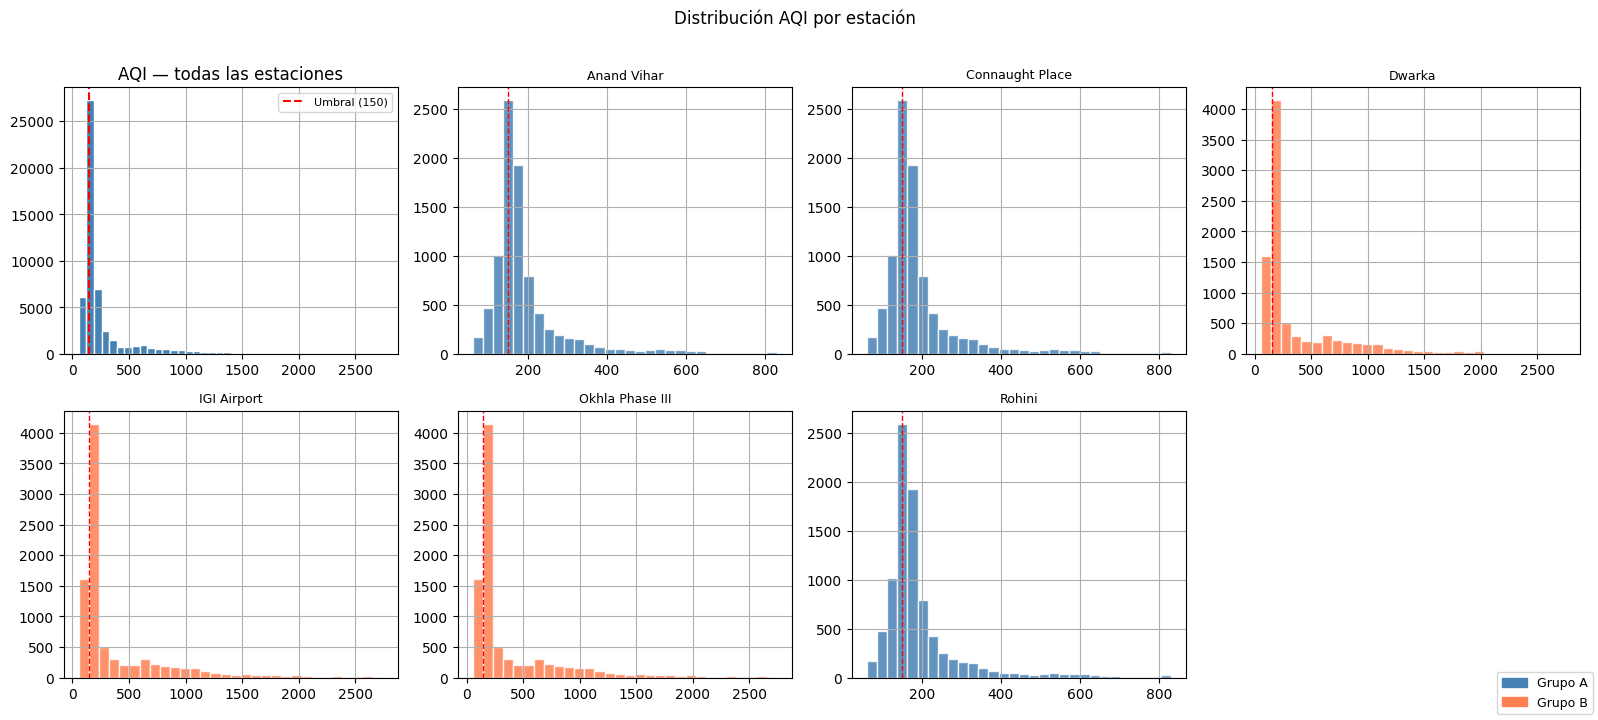

In [ ]:
# Distribución AQI por estación
stations = df_raw[STATION_COL].unique()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

df_raw[TARGET_REG].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('AQI — todas las estaciones')
axes[0].axvline(REGIME_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Umbral ({REGIME_THRESHOLD})')
axes[0].legend(fontsize=8)

for i, st in enumerate(stations):
    color = 'steelblue' if st in GRUPO_A else 'coral'
    df_raw[df_raw[STATION_COL]==st][TARGET_REG].hist(
        bins=30, ax=axes[i+1], color=color, edgecolor='white', alpha=0.85)
    axes[i+1].set_title(st, fontsize=9)
    axes[i+1].axvline(REGIME_THRESHOLD, color='red', linestyle='--', linewidth=1)

patch_a = mpatches.Patch(color='steelblue', label='Grupo A')
patch_b = mpatches.Patch(color='coral',     label='Grupo B')
fig.legend(handles=[patch_a, patch_b], loc='lower right', fontsize=9)
for ax in axes[len(stations)+1:]: ax.set_visible(False)
plt.suptitle('Distribución AQI por estación', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

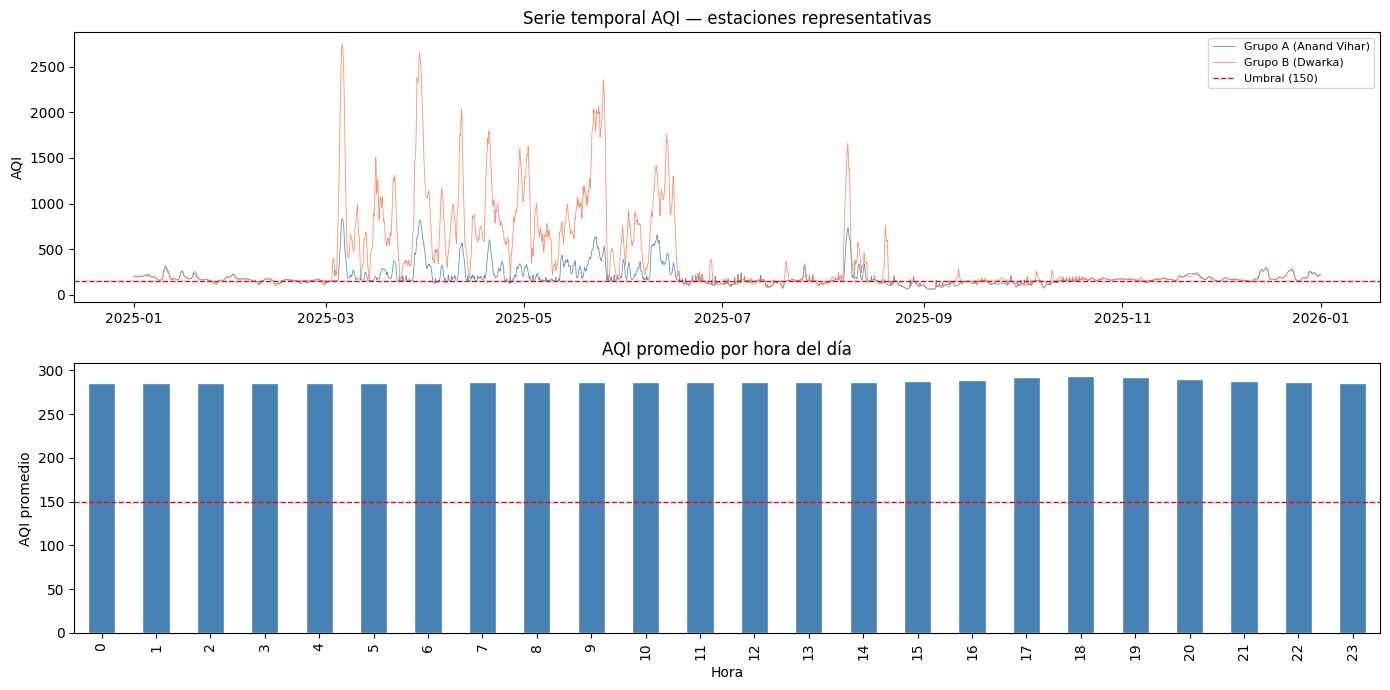

In [ ]:
# Serie temporal y distribución horaria
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for grupo, rep, color in [('Grupo A', REP_A, 'steelblue'), ('Grupo B', REP_B, 'coral')]:
    mask = df_raw[STATION_COL] == rep
    axes[0].plot(df_raw.loc[mask, DATETIME_COL], df_raw.loc[mask, TARGET_REG],
                 label=f'{grupo} ({rep})', color=color, linewidth=0.6, alpha=0.85)
axes[0].axhline(REGIME_THRESHOLD, color='red', linestyle='--', linewidth=1,
                label=f'Umbral ({REGIME_THRESHOLD})')
axes[0].set_title('Serie temporal AQI — estaciones representativas')
axes[0].set_ylabel('AQI')
axes[0].legend(fontsize=8)

df_raw.groupby(df_raw[DATETIME_COL].dt.hour)[TARGET_REG].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axhline(REGIME_THRESHOLD, color='red', linestyle='--', linewidth=1)
axes[1].set_title('AQI promedio por hora del día')
axes[1].set_ylabel('AQI promedio')
axes[1].set_xlabel('Hora')
plt.tight_layout()
plt.show()

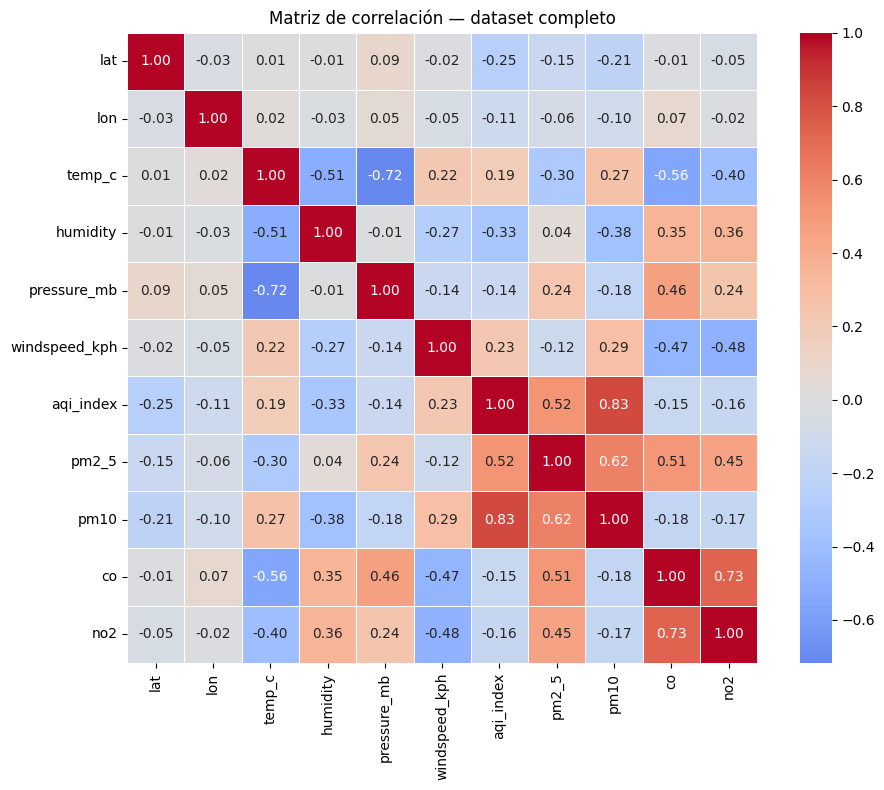

In [ ]:
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Matriz de correlación — dataset completo')
plt.tight_layout()
plt.show()

In [ ]:
# Calcular la matriz de  Pearson
correlation_matrix = df_raw.corr(numeric_only=True)

# Buscar correlaciones con 'aqi_index'
aqi_correlations = correlation_matrix['aqi_index'].drop('aqi_index')

# Ordenar las correlaciones más fuertes
top_5_correlations = aqi_correlations.abs().nlargest(5)

# Mostrar las primeras cinco correlaciones
print("Top 5 variables most correlated with 'aqi_index':")
print(aqi_correlations[top_5_correlations.index])

Top 5 variables most correlated with 'aqi_index':
pm10             0.831292
pm2_5            0.524649
humidity        -0.330126
lat             -0.248147
windspeed_kph    0.233777
Name: aqi_index, dtype: float64


## 3. Hallazgo EDA: duplicación de estaciones

Documentamos y verificamos que las estaciones dentro de cada grupo son
estadísticamente idénticas, justificando el rediseño de la estrategia.

In [ ]:
print('══ Estadísticas Grupo A ══')
print(df_raw[df_raw[STATION_COL].isin(GRUPO_A)].groupby(STATION_COL)[TARGET_REG]
      .describe().round(4))
print('\n══ Estadísticas Grupo B ══')
print(df_raw[df_raw[STATION_COL].isin(GRUPO_B)].groupby(STATION_COL)[TARGET_REG]
      .describe().round(4))

══ Estadísticas Grupo A ══
                  count      mean       std   min    25%    50%    75%    max
location                                                                     
Anand Vihar      8760.0  194.4531  103.5856  61.0  150.0  165.0  199.0  830.0
Connaught Place  8760.0  194.4531  103.5856  61.0  150.0  165.0  199.0  830.0
Rohini           8760.0  194.4531  103.5856  61.0  150.0  165.0  199.0  830.0

══ Estadísticas Grupo B ══
                  count      mean       std   min    25%    50%    75%     max
location                                                                      
Dwarka           8760.0  380.2753  432.6254  56.0  153.0  178.0  424.0  2742.0
IGI Airport      8760.0  380.2753  432.6254  56.0  153.0  178.0  424.0  2742.0
Okhla Phase III  8760.0  380.2753  432.6254  56.0  153.0  178.0  424.0  2742.0


In [ ]:
print('Correlación intra-grupo (esperada ~1.0 si son duplicados):\n')
for grupo, nombre in [(GRUPO_A,'Grupo A'), (GRUPO_B,'Grupo B')]:
    pivot = df_raw[df_raw[STATION_COL].isin(grupo)].pivot_table(
        index=DATETIME_COL, columns=STATION_COL, values=TARGET_REG)
    print(f'── {nombre} ──')
    print(pivot.corr().round(6))
    print()

Correlación intra-grupo (esperada ~1.0 si son duplicados):

── Grupo A ──
location         Anand Vihar  Connaught Place  Rohini
location                                             
Anand Vihar              1.0              1.0     1.0
Connaught Place          1.0              1.0     1.0
Rohini                   1.0              1.0     1.0

── Grupo B ──
location         Dwarka  IGI Airport  Okhla Phase III
location                                             
Dwarka              1.0          1.0              1.0
IGI Airport         1.0          1.0              1.0
Okhla Phase III     1.0          1.0              1.0



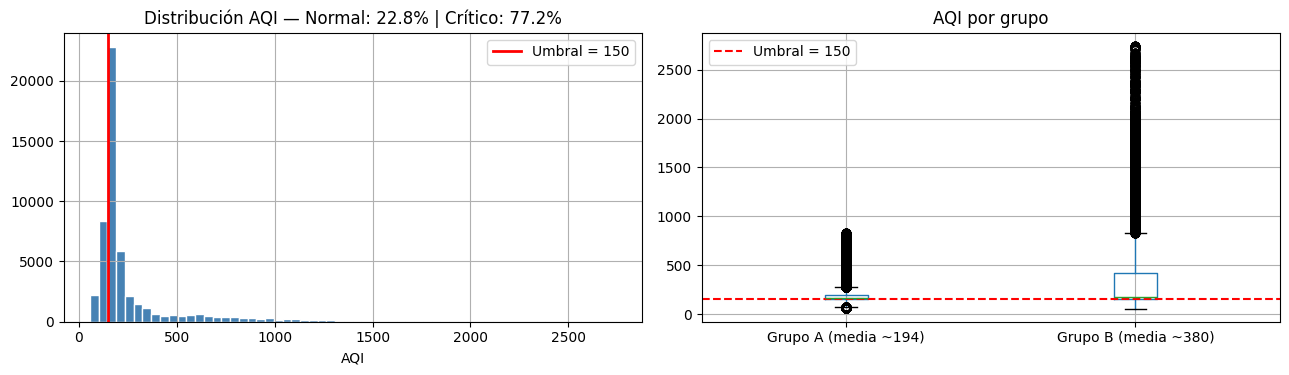

Registros régimen normal  (AQI ≤ 150): 12,003
Registros régimen crítico (AQI > 150): 40,557


In [ ]:
# Explorar el umbral de régimen
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw[TARGET_REG].hist(bins=60, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(REGIME_THRESHOLD, color='red', linewidth=2,
                label=f'Umbral = {REGIME_THRESHOLD}')
normal_pct = (df_raw[TARGET_REG] <= REGIME_THRESHOLD).mean() * 100
axes[0].set_title(
    f'Distribución AQI — Normal: {normal_pct:.1f}% | Crítico: {100-normal_pct:.1f}%')
axes[0].set_xlabel('AQI')
axes[0].legend()

df_raw['grupo'] = df_raw[STATION_COL].apply(
    lambda x: 'Grupo A (media ~194)' if x in GRUPO_A else 'Grupo B (media ~380)')
df_raw.boxplot(column=TARGET_REG, by='grupo', ax=axes[1])
axes[1].axhline(REGIME_THRESHOLD, color='red', linewidth=1.5,
                linestyle='--', label=f'Umbral = {REGIME_THRESHOLD}')
axes[1].set_title('AQI por grupo')
axes[1].set_xlabel('')
axes[1].legend()
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f'Registros régimen normal  (AQI ≤ {REGIME_THRESHOLD}): '
      f'{(df_raw[TARGET_REG] <= REGIME_THRESHOLD).sum():,}')
print(f'Registros régimen crítico (AQI > {REGIME_THRESHOLD}): '
      f'{(df_raw[TARGET_REG] >  REGIME_THRESHOLD).sum():,}')

###OBSERVACIONES POR ESTACIÓN

**Anand Vihar:** Este de Delhi, Zona de transporte pesado. Tiene una de las terminales de buses más grandes de Delhi y estación ferroviaria. Tráfico intenso constante

**Connaught Place:** Centro de Delhi. Distrito comercial y financiero.
Oficinas, restaurantes, alta actividad peatonal.

 **Dwarka:** Suroeste de Delhi. Zona residencial planificada. Amplias avenidas, menos densidad que el centro.

**Okhla Phase III:** Sureste de Delhi. Área industrial. Presencia de fábricas y actividad manufacturera.

**Rohini:** Norte/noroeste de Delhi. Zona residencial amplia.Mezcla de comercio y vivienda.

**Indira Gandhi International Airport (IGI Airport):** Suroeste de Delhi.
Aeropuerto internacional principal con alto tráfico aéreo y vehicular asociado.

Las estaciones del estudio se dividen en dos grupos donde los valores de media, desviación estándar, mínimos y máximos son matemáticamente idénticos, lo que sugiere un error en la fuente de la API o en el proceso de agregación donde una sola señal de sensor fue asignada a múltiples etiquetas de ubicación.

Grupo A: Anand Vihar, Connaught Place y Rohini. Estas tres estaciones presentan estadísticas idénticas, con un promedio de AQI de aproximadamente 194.45 y un valor máximo de 830.0.

Grupo B : Dwarka, IGI Airport y Okhla Phase III. Este grupo comparte un perfil de contaminación mucho más agresivo, con una media de 380.27 y picos extremos de hasta 2742.0.Esta duplicación significa que cualquier intento de realizar un "análisis espacial" comparativo entre estaciones no será fructífero

###DECISIÓN METODOLÓGICA
──────────────────────────────────────────────────────────────────────────────────────
Las 6 estaciones presentan estadísticas matemáticamente idénticas
dentro de cada grupo (correlación ~1.0). Una sola señal de sensor
fue asignada a múltiples etiquetas de ubicación.

Consecuencia: Modelar por estación equivale a entrenar sobre datos
duplicados. Entrenar con las 6 estaciones equivale a replicar los datos 3 veces,
inflando artificialmente las métricas.
Estrategia rediseñada I:

  • Eje principal: RÉGIMEN DE CONTAMINACIÓN
    → Normal (AQI ≤ umbral) vs. Crítico (AQI > umbral)
  • Cada régimen se modela con 4 algoritmos clásicos + LSTM (con lag temporal y sin lag temporal)
  • Se compara el mejor de cada segmento entre sí y contra el global

Estrategia rediseñada II:
usar UNA estación representativa por grupo.

  • Grupo A → representada por: {rep_a}
  
  • Grupo B → representada por: {rep_b}

Esto preserva la comparación entre perfiles de contaminación distintos
(media ~194 vs. ~380) sin duplicar la información.
──────────────────────────────────────────────────────────────────────────────────────

## 4. Selección de estaciones representativas

A partir de aquí **todo el análisis** usa únicamente las dos estaciones
representativas. El dataset `df` que se construye aquí reemplaza al
`df_raw` completo para el resto del notebook.

Dataset filtrado — Filas: 17,520  |  Columnas: 16
Estaciones: ['Anand Vihar' 'Dwarka']

              count    mean     std   min    25%    50%    75%     max
location                                                              
Anand Vihar  8760.0  194.45  103.59  61.0  150.0  165.0  199.0   830.0
Dwarka       8760.0  380.28  432.63  56.0  153.0  178.0  424.0  2742.0


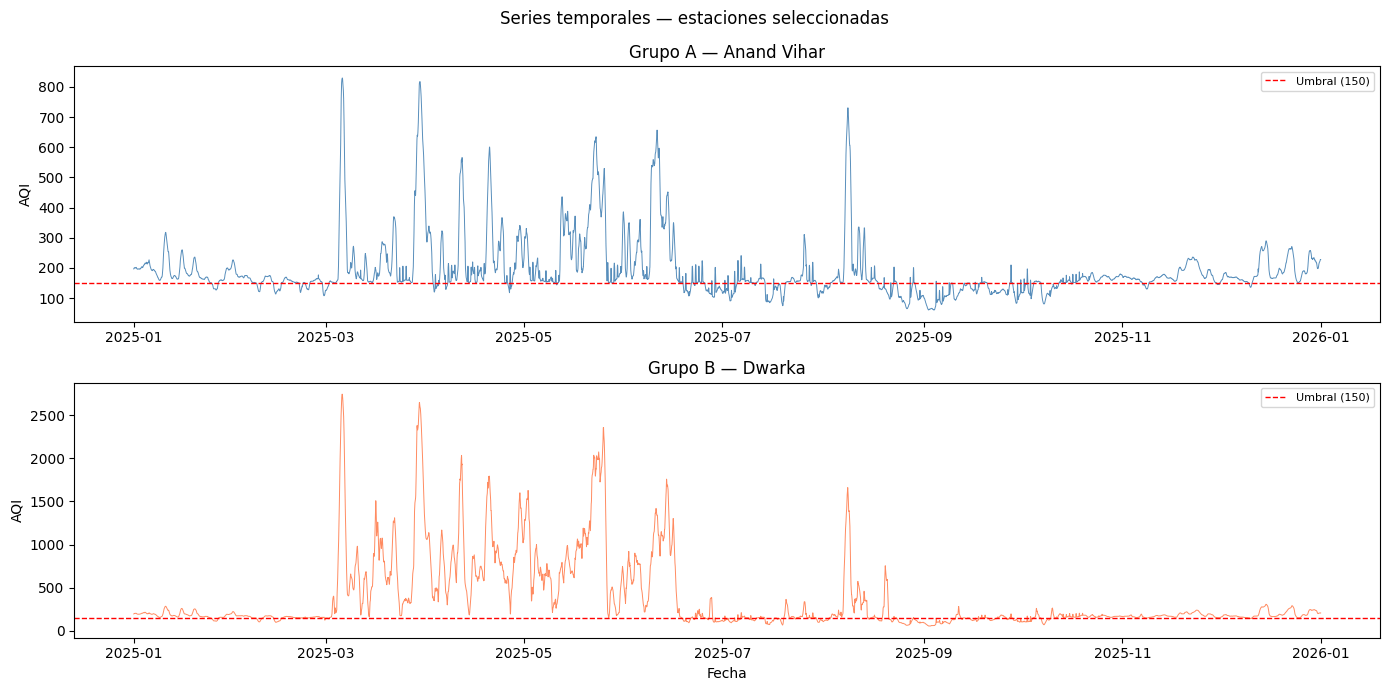

In [ ]:
# Filtrar solo las dos estaciones representativas
df = df_raw[df_raw[STATION_COL].isin([REP_A, REP_B])].copy().reset_index(drop=True)

# Definir las columnas a eliminar
columnas_a_eliminar = ['lat', 'lon']

# Eliminar las columnas sin varianza
df.drop(columnas_a_eliminar, axis=1, inplace=True)

print(f'Dataset filtrado — Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
print(f'Estaciones: {df[STATION_COL].unique()}')
print()
print(df.groupby(STATION_COL)[TARGET_REG].describe().round(2))

# Visualizar las dos series
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, (rep, color, grupo) in zip(axes, [
    (REP_A, 'steelblue', 'A'), (REP_B, 'coral', 'B')
]):
    mask = df[STATION_COL] == rep
    ax.plot(df.loc[mask, DATETIME_COL], df.loc[mask, TARGET_REG],
            color=color, linewidth=0.7, alpha=0.9)
    ax.axhline(REGIME_THRESHOLD, color='red', linestyle='--',
               linewidth=1, label=f'Umbral ({REGIME_THRESHOLD})')
    ax.set_title(f'Grupo {grupo} — {rep}')
    ax.set_ylabel('AQI')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Fecha')
plt.suptitle('Series temporales — estaciones seleccionadas', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Preprocesamiento y feature engineering



In [ ]:
def aqi_to_category(aqi):
    if aqi <= 50:    return 'Buena'
    elif aqi <= 100: return 'Moderada'
    elif aqi <= 150: return 'Insalubre_sensibles'
    elif aqi <= 200: return 'Insalubre'
    elif aqi <= 300: return 'Muy_insalubre'
    else:            return 'Peligrosa'

if TARGET_CLF not in df.columns:
    df[TARGET_CLF] = df[TARGET_REG].apply(aqi_to_category)
    print(f'✓ Columna "{TARGET_CLF}" creada')
print(df[TARGET_CLF].value_counts())

✓ Columna "AQI_category" creada
AQI_category
Insalubre              7961
Peligrosa              3487
Insalubre_sensibles    3260
Muy_insalubre          2071
Moderada                741
Name: count, dtype: int64


### Aclaración metodológica:
Esta clasificaciónde AQI corresponde al estándar definido por la EPA (U.S. Environmental Protection Agency) y adoptado por muchas plataformas a nivel mundial.

Esta clasificación se basa en evidencia epidemiolígica de salud y estándares de calidad de aires, en una escala común (0-500).
Los nombres de las categorías reflejan mensajes de salud pública, no son términos técnicos.

El AQI comunica riesgo a corto plazo y usa límites menos estrictos que las guías de la OMS, que apuntan a la exposición crónica. Por ejemplo, un valor de AQI "bueno" no significa aire óptimo a largo plazo, sólo que no hay riesgo inmediato-

| AQI | Categoría| Base sanitaria|
|-----------|-----|----------|
| **≤ 50** | Buena | No se observan efectos en salud |
| **51-100** | Moderada | Puede afectar a personas muy sensibles |
| **101-150** | Insalubre para sensibles | Impacta a asmáticos, niños, adultos mayores |
| **151-200** | Insalubre | Empiezan efectos en población general |
| **201-300** | Muy Insalubre | Riesgo serio para todos |
| **> 300** | Peligrosa | Emergencia sanitaria |


In [ ]:
num_cols = [c for c in df.select_dtypes(include=np.number).columns
            if c != TARGET_REG]
for col in num_cols:
    if df[col].isnull().any():
        df[col] = df.groupby(STATION_COL)[col].transform(
            lambda x: x.fillna(x.median()))
print(f'✓ Nulos restantes: {df.isnull().sum().sum()}')

✓ Nulos restantes: 0


In [ ]:
# ── Feature engineering temporal ───────────────────────────────────────────

df['hour']       = df[DATETIME_COL].dt.hour
df['month']      = df[DATETIME_COL].dt.month
df['dayofweek']  = df[DATETIME_COL].dt.dayofweek
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Lags temporales (resolución horaria: shift(1)=1h, shift(6)=6h, shift(24)=1 día)
df['AQI_lag1']  = df.groupby(STATION_COL)[TARGET_REG].shift(1)
df['AQI_lag6']  = df.groupby(STATION_COL)[TARGET_REG].shift(6)
df['AQI_lag24'] = df.groupby(STATION_COL)[TARGET_REG].shift(24)
df['AQI_roll7'] = df.groupby(STATION_COL)[TARGET_REG].transform(
    lambda x: x.rolling(7, min_periods=1).mean())
df = df.dropna().reset_index(drop=True)

LAG_COLS = ['AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']

print('✓ Features temporales y lags creados')
print(f'  Lags: {LAG_COLS}')
print(f'  Columnas totales: {list(df.columns)}')

✓ Features temporales y lags creados
  Lags: ['AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']
  Columnas totales: ['date_ist', 'time_ist', 'location', 'temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'condition_text', 'description', 'aqi_index', 'pm2_5', 'pm10', 'co', 'no2', 'datetime', 'grupo', 'AQI_category', 'hour', 'month', 'dayofweek', 'is_weekend', 'AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']


In [ ]:
EXCLUDE_COLS = [TARGET_REG, TARGET_CLF, STATION_COL,
                DATE_COL, TIME_COL, DATETIME_COL,
                'grupo', 'target_clf_enc', 'regime']

# Features completos (con lags) — usados para modelos clásicos
FEATURE_COLS = [c for c in df.select_dtypes(include=np.number).columns
                if c not in EXCLUDE_COLS]

# Features sin lags — LSTM v2
FEATURE_COLS_LSTM = [c for c in FEATURE_COLS if c not in LAG_COLS]

print(f'Features clásicos + LSTM v1 ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Features LSTM v2            ({len(FEATURE_COLS_LSTM)}): {FEATURE_COLS_LSTM}')

le_global = LabelEncoder()
df['target_clf_enc'] = le_global.fit_transform(df[TARGET_CLF])
CLASS_NAMES = le_global.classes_
print(f'Clases: {list(CLASS_NAMES)}')

Features clásicos + LSTM v1 (16): ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'month', 'dayofweek', 'is_weekend', 'AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']
Features LSTM v2            (12): ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'month', 'dayofweek', 'is_weekend']
Clases: ['Insalubre', 'Insalubre_sensibles', 'Moderada', 'Muy_insalubre', 'Peligrosa']


## 6. Segmentación por régimen de contaminación

In [ ]:
df['regime']   = np.where(df[TARGET_REG] <= REGIME_THRESHOLD, 'normal', 'critico')
df_normal      = df[df['regime']=='normal' ].copy().reset_index(drop=True)
df_critico     = df[df['regime']=='critico'].copy().reset_index(drop=True)
df_global_seg  = df.copy()

# Encoder independiente por subset (las clases pueden diferir entre segmentos)
def encode_clf(data):
    le = LabelEncoder()
    return le.fit_transform(data[TARGET_CLF]), le

df_normal['target_clf_enc'],      le_normal  = encode_clf(df_normal)
df_critico['target_clf_enc'],     le_critico = encode_clf(df_critico)
df_global_seg['target_clf_enc'],  le_gseg    = encode_clf(df_global_seg)

print(f'Normal:  {len(df_normal):,} filas  |  clases: {list(le_normal.classes_)}')
print(f'Crítico: {len(df_critico):,} filas  |  clases: {list(le_critico.classes_)}')
print(f'Global:  {len(df_global_seg):,} filas  |  clases: {list(le_gseg.classes_)}')

Normal:  4,001 filas  |  clases: ['Insalubre_sensibles', 'Moderada']
Crítico: 13,471 filas  |  clases: ['Insalubre', 'Muy_insalubre', 'Peligrosa']
Global:  17,472 filas  |  clases: ['Insalubre', 'Insalubre_sensibles', 'Moderada', 'Muy_insalubre', 'Peligrosa']


## 7. Funciones preparatorias

In [ ]:
def prepare_data(data, features, target, test_size=TEST_SIZE,
                 scale=True, shuffle=True):
    X = data[features].values
    y = data[target].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=SEED, shuffle=shuffle)
    scaler = None
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
    return X_tr, X_te, y_tr, y_te, scaler


def create_sequences(X, y, n_steps):
    Xs, ys = [], []
    for i in range(len(X) - n_steps):
        Xs.append(X[i : i + n_steps])
        ys.append(y[i + n_steps])
    return np.array(Xs), np.array(ys)


def prepare_sequences(data, features, target, n_steps=N_STEPS,
                      test_size=TEST_SIZE):
    """Escala X e y, crea secuencias y hace split temporal (sin shuffle)."""
    x_scaler = StandardScaler()
    X_all    = x_scaler.fit_transform(data[features].values)
    y_scaler = StandardScaler()
    y_all    = y_scaler.fit_transform(
        data[target].values.reshape(-1, 1)).flatten()
    X_seq, y_seq = create_sequences(X_all, y_all, n_steps)
    split = int(len(X_seq) * (1 - test_size))
    return (X_seq[:split], X_seq[split:],
            y_seq[:split], y_seq[split:],
            x_scaler, y_scaler)


def eval_clf(model, X_te, y_te, label=''):
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    try:
        y_prob = (model.predict_proba(X_te)
                  if hasattr(model, 'predict_proba') else model.predict(X_te))
        n_cls = len(np.unique(y_te))
        auc = (roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')
               if n_cls > 2 else roc_auc_score(y_te, y_prob[:, 1]))
    except Exception:
        auc = np.nan
    m = {'modelo': label, 'accuracy': acc, 'f1_weighted': f1, 'auc_roc': auc}
    print(f'  [{label:<28}]  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    return m


def eval_reg(model, X_te, y_te, label=''):
    y_pred = model.predict(X_te)
    if isinstance(y_pred, np.ndarray) and y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    m = {'modelo': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f'  [{label:<28}]  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return m


class DNNWrapperClf:
    def __init__(self, m): self.model = m
    def predict(self, X):       return np.argmax(self.model.predict(X, verbose=0), axis=1)
    def predict_proba(self, X): return self.model.predict(X, verbose=0)

class DNNWrapperReg:
    def __init__(self, m): self.model = m
    def predict(self, X):  return self.model.predict(X, verbose=0).flatten()


def build_dnn_clf(input_dim, n_cls):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(64,  activation='relu'), layers.Dropout(0.2),
        layers.Dense(n_cls, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_dnn_reg(input_dim):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(64,  activation='relu'), layers.Dropout(0.2),
        layers.Dense(1, activation='linear')
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

def build_lstm(n_steps, n_features):
    m = keras.Sequential([
        layers.Input(shape=(n_steps, n_features)),
        layers.LSTM(128, return_sequences=True), layers.Dropout(0.2),
        layers.LSTM(64),  layers.Dropout(0.2),
        layers.Dense(32,  activation='relu'),
        layers.Dense(1,   activation='linear')
    ])
    optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
    m.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return m

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True)

early_stop_lstm = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr_lstm = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)

print('✓ Funciones auxiliares definidas')

✓ Funciones auxiliares definidas


## 8. ETAPA 1 — Clasificación (4 modelos × 3 segmentos)

Entrenamos Regresión Logística, Random Forest, XGBoost y DNN
sobre los tres segmentos: **Normal**, **Crítico** y **Global**.

In [ ]:
results_clf = []

SEGMENTOS_CLF = [
    ('Global',  df_global_seg, le_gseg),
    ('Normal',  df_normal,     le_normal),
    ('Critico', df_critico,    le_critico),
]

for seg_name, df_seg, le_seg in SEGMENTOS_CLF:
    n_cls_seg = len(le_seg.classes_)
    print(f'\n══ Clasificación — {seg_name} ({len(df_seg):,} filas | {n_cls_seg} clases) ══')
    X_tr, X_te, y_tr, y_te, _ = prepare_data(df_seg, FEATURE_COLS, 'target_clf_enc')

    # 1. Regresión logística
    lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
    lr.fit(X_tr, y_tr)
    m = eval_clf(lr, X_te, y_te, f'LogReg_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'LogReg'
    results_clf.append(m)

    # 2. Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight='balanced')
    rf.fit(X_tr, y_tr)
    m = eval_clf(rf, X_te, y_te, f'RF_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'RF'
    results_clf.append(m)

    # 3. XGBoost
    xgb_c = XGBClassifier(n_estimators=100, eval_metric='mlogloss',
                           random_state=SEED, verbosity=0)
    xgb_c.fit(X_tr, y_tr)
    m = eval_clf(xgb_c, X_te, y_te, f'XGB_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'XGB'
    results_clf.append(m)

    # 4. DNN
    dnn_c = build_dnn_clf(len(FEATURE_COLS), n_cls_seg)
    dnn_c.fit(X_tr, y_tr, validation_split=0.15, epochs=100,
              batch_size=32, callbacks=[early_stop], verbose=0)
    m = eval_clf(DNNWrapperClf(dnn_c), X_te, y_te, f'DNN_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'DNN'
    results_clf.append(m)

print('\n✓ Clasificación completada')


══ Clasificación — Global (17,472 filas | 5 clases) ══
  [LogReg_Global               ]  Acc=0.8884  F1=0.8904  AUC=0.9836
  [RF_Global                   ]  Acc=0.9717  F1=0.9717  AUC=0.9982
  [XGB_Global                  ]  Acc=0.9757  F1=0.9757  AUC=0.9987
  [DNN_Global                  ]  Acc=0.9548  F1=0.9546  AUC=0.9962

══ Clasificación — Normal (4,001 filas | 2 clases) ══
  [LogReg_Normal               ]  Acc=0.9738  F1=0.9742  AUC=0.9975
  [RF_Normal                   ]  Acc=0.9838  F1=0.9837  AUC=0.9986
  [XGB_Normal                  ]  Acc=0.9863  F1=0.9862  AUC=0.9990
  [DNN_Normal                  ]  Acc=0.9788  F1=0.9786  AUC=0.9947

══ Clasificación — Critico (13,471 filas | 3 clases) ══
  [LogReg_Critico              ]  Acc=0.9544  F1=0.9561  AUC=0.9964
  [RF_Critico                  ]  Acc=0.9822  F1=0.9822  AUC=0.9991
  [XGB_Critico                 ]  Acc=0.9803  F1=0.9804  AUC=0.9991
  [DNN_Critico                 ]  Acc=0.9711  F1=0.9713  AUC=0.9979

✓ Clasificación

F1-score (weighted) — Clasificación:


algoritmo,DNN,LogReg,RF,XGB
segmento,,,,
Critico,0.9713,0.9561,0.9822,0.9804
Global,0.9546,0.8904,0.9717,0.9757
Normal,0.9786,0.9742,0.9837,0.9862


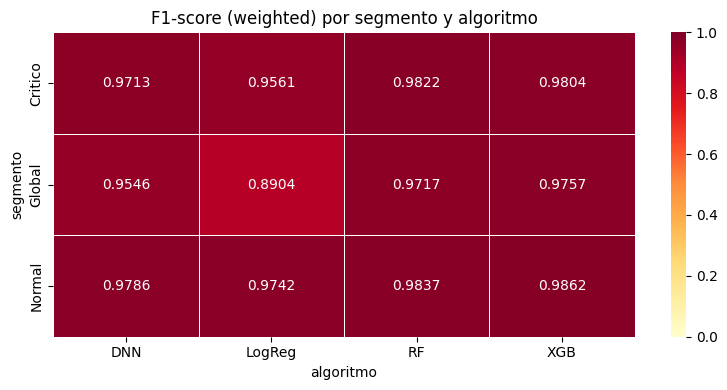

In [ ]:
df_clf = pd.DataFrame(results_clf)
pivot_clf = df_clf.pivot_table(
    index='segmento', columns='algoritmo', values='f1_weighted').round(4)

print('F1-score (weighted) — Clasificación:')
display(pivot_clf)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot_clf, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('F1-score (weighted) por segmento y algoritmo')
plt.tight_layout()
plt.show()

## 9. ETAPA 2 — Regresión clásica (4 modelos × 3 segmentos)

Predecimos el valor numérico del AQI con Regresión Lineal, Random Forest,
XGBoost y DNN sobre los tres segmentos con lags temporales.

In [ ]:
results_reg = []

SEGMENTOS_REG = [
    ('Global',  df_global_seg),
    ('Normal',  df_normal),
    ('Critico', df_critico),
]

for seg_name, df_seg in SEGMENTOS_REG:
    print(f'\n══ Regresión clásica — {seg_name} ({len(df_seg):,} filas) ══')
    X_tr, X_te, y_tr, y_te, _ = prepare_data(df_seg, FEATURE_COLS, TARGET_REG)

    # 1. Regresión lineal
    lr_r = LinearRegression()
    lr_r.fit(X_tr, y_tr)
    m = eval_reg(lr_r, X_te, y_te, f'RegLineal_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'RegLineal'
    results_reg.append(m)

    # 2. Random Forest
    rf_r = RandomForestRegressor(n_estimators=100, random_state=SEED)
    rf_r.fit(X_tr, y_tr)
    m = eval_reg(rf_r, X_te, y_te, f'RF_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'RF'
    results_reg.append(m)

    # 3. XGBoost
    xgb_r = XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0)
    xgb_r.fit(X_tr, y_tr)
    m = eval_reg(xgb_r, X_te, y_te, f'XGB_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'XGB'
    results_reg.append(m)

    # 4. DNN
    dnn_r = build_dnn_reg(len(FEATURE_COLS))
    dnn_r.fit(X_tr, y_tr, validation_split=0.15, epochs=100,
              batch_size=32, callbacks=[early_stop], verbose=0)
    m = eval_reg(DNNWrapperReg(dnn_r), X_te, y_te, f'DNN_{seg_name}')
    m['segmento'] = seg_name; m['algoritmo'] = 'DNN'
    results_reg.append(m)

print('\n✓ Regresión clásica completada')


══ Regresión clásica — Global (17,472 filas) ══
  [RegLineal_Global            ]  RMSE=7.1212  MAE=3.9782  R²=0.9995
  [RF_Global                   ]  RMSE=9.0956  MAE=3.9326  R²=0.9992
  [XGB_Global                  ]  RMSE=11.4542  MAE=4.7900  R²=0.9987
  [DNN_Global                  ]  RMSE=138.9058  MAE=98.5794  R²=0.8126

══ Regresión clásica — Normal (4,001 filas) ══
  [RegLineal_Normal            ]  RMSE=3.4918  MAE=1.9061  R²=0.9738
  [RF_Normal                   ]  RMSE=3.3265  MAE=1.5708  R²=0.9762
  [XGB_Normal                  ]  RMSE=3.1303  MAE=1.5757  R²=0.9790
  [DNN_Normal                  ]  RMSE=113.5665  MAE=111.8974  R²=-26.6932

══ Regresión clásica — Critico (13,471 filas) ══
  [RegLineal_Critico           ]  RMSE=8.8456  MAE=4.8531  R²=0.9994
  [RF_Critico                  ]  RMSE=10.9353  MAE=4.8844  R²=0.9991
  [XGB_Critico                 ]  RMSE=12.2570  MAE=5.4588  R²=0.9989
  [DNN_Critico                 ]  RMSE=155.6858  MAE=127.4377  R²=0.8159

✓ Regres

RMSE por segmento (menor = mejor):


algoritmo,DNN,RF,RegLineal,XGB
segmento,,,,
Critico,155.6858,10.9353,8.8456,12.2570
Global,138.9058,9.0956,7.1212,11.4542
Normal,113.5665,3.3265,3.4918,3.1303


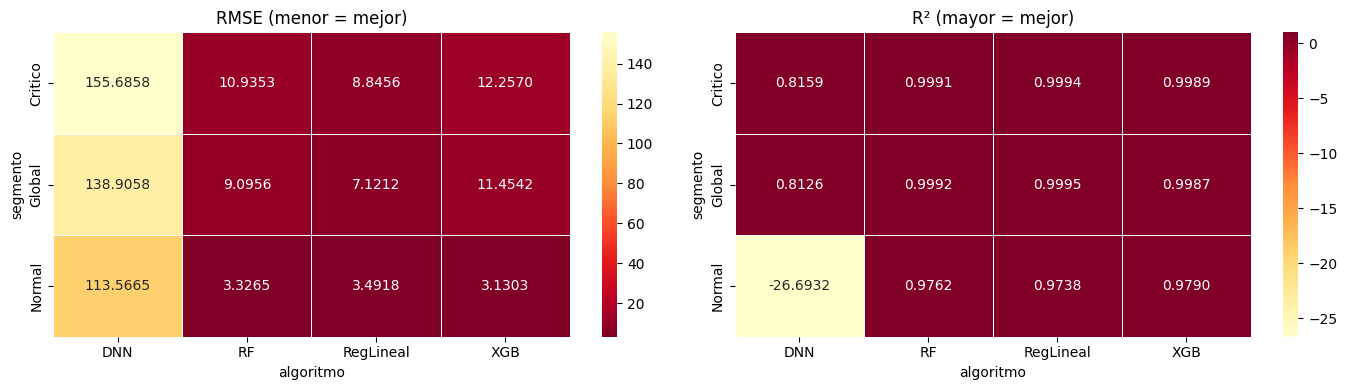

In [ ]:
df_reg = pd.DataFrame(results_reg)

pivot_rmse = df_reg.pivot_table(
    index='segmento', columns='algoritmo', values='RMSE').round(4)
pivot_r2 = df_reg.pivot_table(
    index='segmento', columns='algoritmo', values='R2').round(4)

print('RMSE por segmento (menor = mejor):')
display(pivot_rmse)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(pivot_rmse, annot=True, fmt='.4f', cmap='YlOrRd_r',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('RMSE (menor = mejor)')
sns.heatmap(pivot_r2, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('R² (mayor = mejor)')
plt.tight_layout()
plt.show()


── Importancia de features — RegLineal (Global) ──


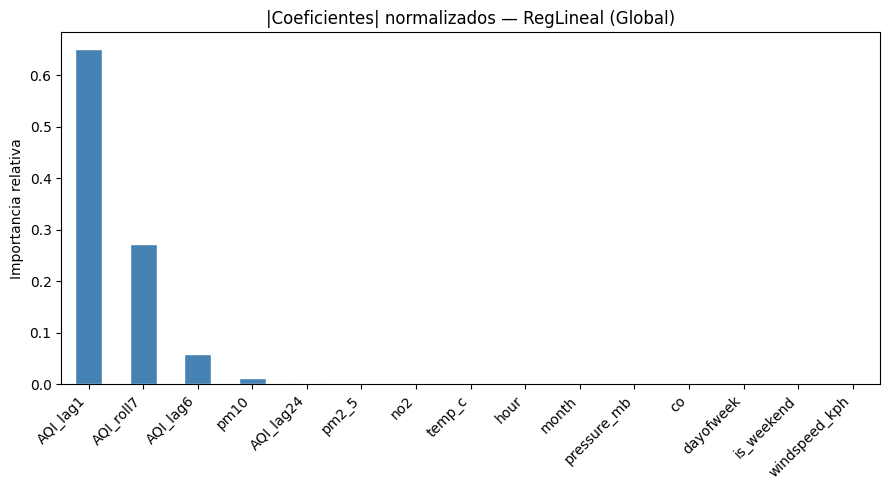

  Top 5 features: ['AQI_lag1', 'AQI_roll7', 'AQI_lag6', 'pm10', 'AQI_lag24']

── Importancia de features — RegLineal (Critico) ──


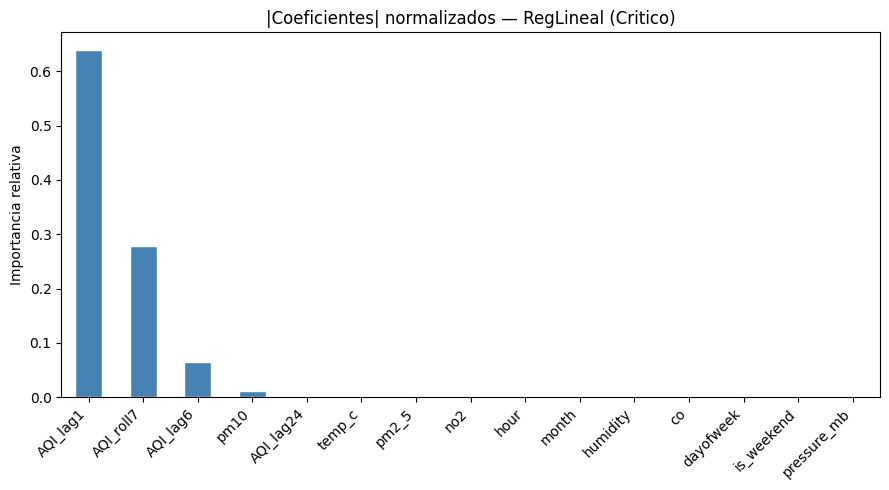

  Top 5 features: ['AQI_lag1', 'AQI_roll7', 'AQI_lag6', 'pm10', 'AQI_lag24']

── Importancia de features — XGB (Normal) ──


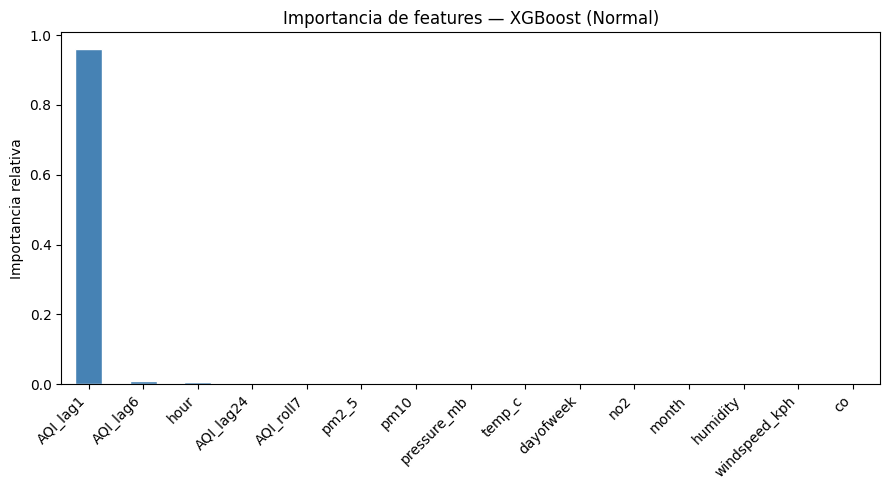

  Top 5 features: ['AQI_lag1', 'AQI_lag6', 'hour', 'AQI_lag24', 'AQI_roll7']


In [ ]:
# ── Importancia de features — Global (RegLineal), Crítico (RegLineal), Normal (XGB) ──

# Configuración de cada caso
casos = [
    ('Global',  df_global_seg, 'RegLineal'),
    ('Critico', df_critico,    'RegLineal'),
    ('Normal',  df_normal,     'XGB'),
]

for seg_name, df_seg, algo in casos:
    print(f'\n── Importancia de features — {algo} ({seg_name}) ──')

    X_tr, X_te, y_tr, y_te, _ = prepare_data(df_seg, FEATURE_COLS, TARGET_REG)

    if algo == 'RegLineal':
        modelo = LinearRegression()
        modelo.fit(X_tr, y_tr)
        # Regresión lineal no tiene feature_importances_ — usamos |coeficientes| normalizados
        importances = pd.Series(
            np.abs(modelo.coef_), index=FEATURE_COLS
        )
        importances = importances / importances.sum()   # normalizar a [0,1]
        titulo = f'|Coeficientes| normalizados — RegLineal ({seg_name})'

    elif algo == 'XGB':
        modelo = XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0)
        modelo.fit(X_tr, y_tr)
        importances = pd.Series(
            modelo.feature_importances_, index=FEATURE_COLS
        )
        titulo = f'Importancia de features — XGBoost ({seg_name})'

    importances = importances.sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    importances.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title(titulo)
    plt.ylabel('Importancia relativa')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f'  Top 5 features: {list(importances.head(5).index)}')

## 10. ETAPA 3 — LSTM (3 segmentos: normal, crítico, global)

Entrenamos dos versiones del LSTM sobre cada segmento:

| Versión | Features | Ventaja temporal |
|---------|----------|------------------|
| **LSTM v1** | Con lags (`FEATURE_COLS`) | Explícita — `AQI_lag1/6/24` |
| **LSTM v2** | Sin lags (`FEATURE_COLS_LSTM`) | Implícita — memoria de 24 pasos |

Ambas versiones usan el mismo `build_lstm`, target escalado con
`StandardScaler`, y callbacks con mayor paciencia que los modelos clásicos.

### 10a. LSTM v1 — con lags temporales

In [ ]:
# ── LSTM primera ejecución: con FEATURE_COLS (incluye lags) ──────────────────
results_lstm_v1 = []
lstm_histories_v1 = {}
lstm_preds_v1     = {}

print('══ LSTM v1 — features CON lags ══')
print(f'  Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'  Ventana temporal: {N_STEPS} pasos = {N_STEPS} horas')

SEGMENTOS_LSTM = [
    ('Global',  df_global_seg),
    ('Normal',  df_normal),
    ('Critico', df_critico),
]

for seg_name, df_seg in SEGMENTOS_LSTM:
    print(f'\n══ LSTM v1 — {seg_name} ({len(df_seg):,} filas) ══')
    df_seg_sorted = df_seg.sort_values([STATION_COL, DATETIME_COL]).reset_index(drop=True)

    X_tr_s, X_te_s, y_tr_s, y_te_s, _, y_scaler = prepare_sequences(
        df_seg_sorted, FEATURE_COLS, TARGET_REG, n_steps=N_STEPS)
    print(f'  Secuencias — train: {X_tr_s.shape}  test: {X_te_s.shape}')

    lstm_m = build_lstm(N_STEPS, len(FEATURE_COLS))
    history = lstm_m.fit(
        X_tr_s, y_tr_s,
        validation_split=0.15,
        epochs=200, batch_size=64,
        callbacks=[early_stop_lstm, reduce_lr_lstm],
        verbose=0
    )
    lstm_histories_v1[seg_name] = history
    print(f'  Épocas entrenadas: {len(history.history["loss"])}')

    y_pred_sc = lstm_m.predict(X_te_s, verbose=0).flatten()
    y_pred    = y_scaler.inverse_transform(y_pred_sc.reshape(-1,1)).flatten()
    y_te_orig = y_scaler.inverse_transform(y_te_s.reshape(-1,1)).flatten()
    lstm_preds_v1[seg_name] = (y_te_orig, y_pred)

    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred))
    mae  = mean_absolute_error(y_te_orig, y_pred)
    r2   = r2_score(y_te_orig, y_pred)
    print(f'  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    results_lstm_v1.append({
        'modelo': f'LSTM_v1_{seg_name}', 'segmento': seg_name,
        'algoritmo': 'LSTM_v1', 'RMSE': rmse, 'MAE': mae, 'R2': r2
    })

print('\n✓ LSTM v1 completado')

══ LSTM v1 — features CON lags ══
  Features (16): ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'month', 'dayofweek', 'is_weekend', 'AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']
  Ventana temporal: 24 pasos = 24 horas

══ LSTM v1 — Global (17,472 filas) ══
  Secuencias — train: (13958, 24, 16)  test: (3490, 24, 16)
  Épocas entrenadas: 66
  RMSE=12.7319  MAE=8.0465  R²=0.9876

══ LSTM v1 — Normal (4,001 filas) ══
  Secuencias — train: (3181, 24, 16)  test: (796, 24, 16)
  Épocas entrenadas: 30
  RMSE=14.6989  MAE=11.7125  R²=0.6629

══ LSTM v1 — Critico (13,471 filas) ══
  Secuencias — train: (10757, 24, 16)  test: (2690, 24, 16)
  Épocas entrenadas: 30
  RMSE=41.3834  MAE=25.0306  R²=0.9349

✓ LSTM v1 completado


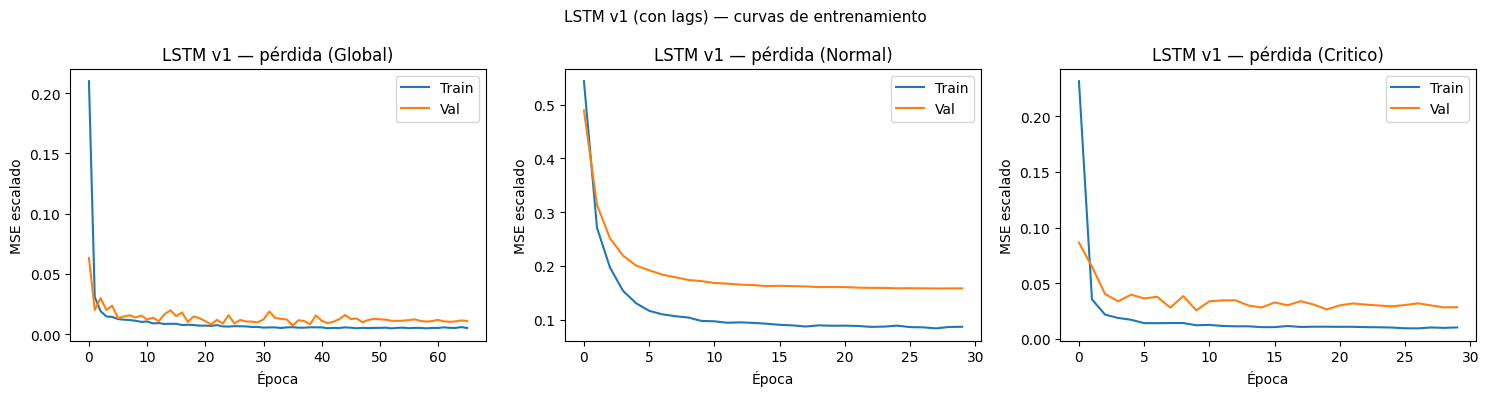

In [ ]:
# ── Curvas de pérdida — LSTM v1 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (seg_name, history) in zip(axes, lstm_histories_v1.items()):
    ax.plot(history.history['loss'],     label='Train')
    ax.plot(history.history['val_loss'], label='Val')
    ax.set_title(f'LSTM v1 — pérdida ({seg_name})')
    ax.set_xlabel('Época'); ax.set_ylabel('MSE escalado'); ax.legend()
plt.suptitle('LSTM v1 (con lags) — curvas de entrenamiento', fontsize=11)
plt.tight_layout(); plt.show()

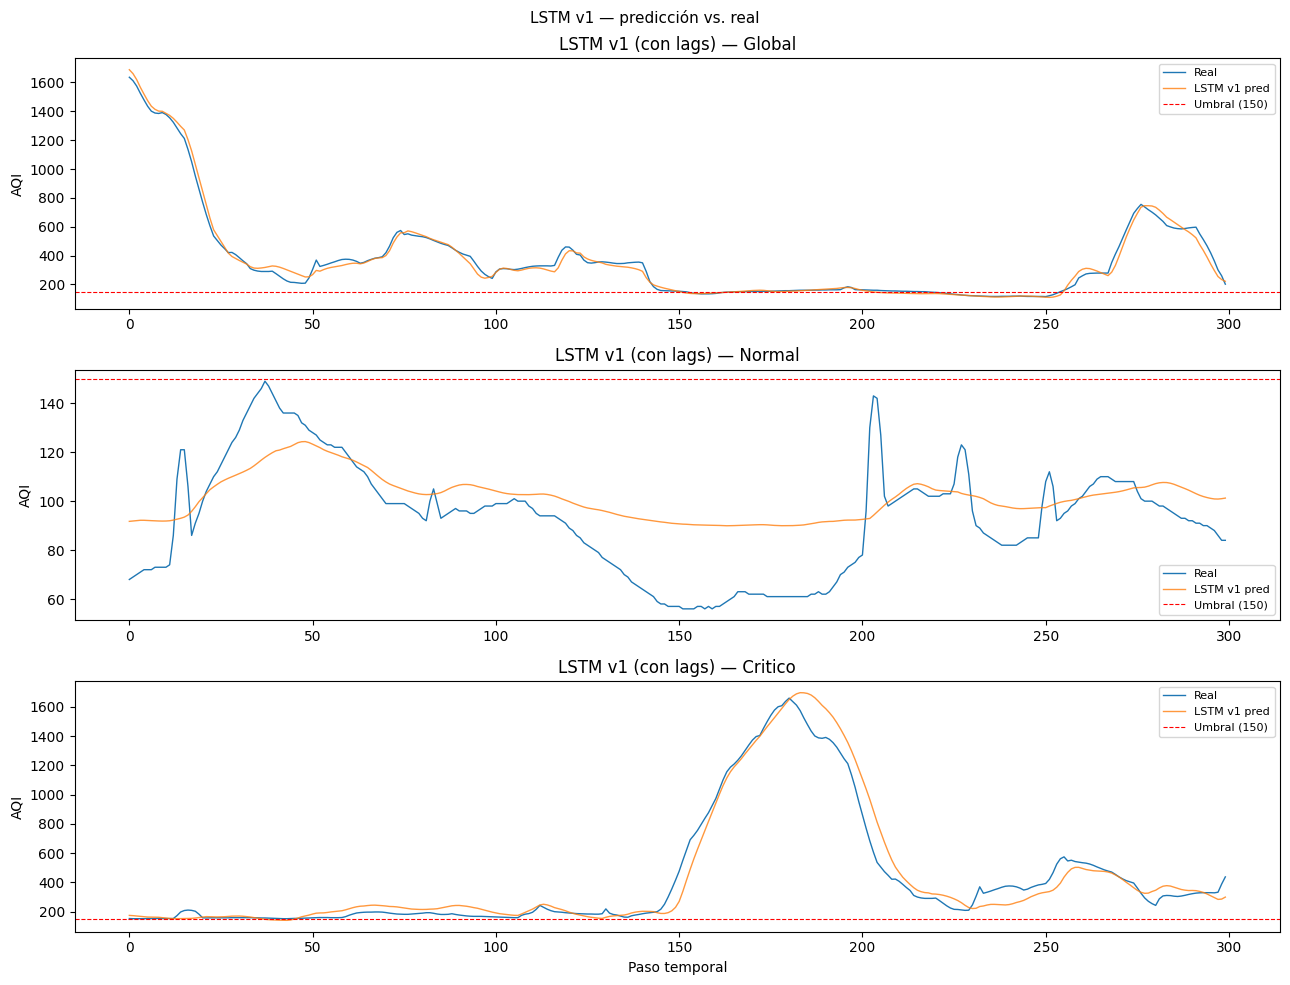

In [ ]:
# ── Predicción vs. real — LSTM v1 ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
N_PLOT = 300
for ax, (seg_name, (y_real, y_pred)) in zip(axes, lstm_preds_v1.items()):
    ax.plot(y_real[:N_PLOT], label='Real',         linewidth=1)
    ax.plot(y_pred[:N_PLOT], label='LSTM v1 pred', linewidth=1, alpha=0.8)
    ax.axhline(REGIME_THRESHOLD, color='red', linestyle='--',
               linewidth=0.8, label=f'Umbral ({REGIME_THRESHOLD})')
    ax.set_title(f'LSTM v1 (con lags) — {seg_name}')
    ax.set_ylabel('AQI'); ax.legend(fontsize=8)
axes[-1].set_xlabel('Paso temporal')
plt.suptitle('LSTM v1 — predicción vs. real', fontsize=11)
plt.tight_layout(); plt.show()

### 10b. Segunda ejecución del LSTM — sin lags temporales



In [ ]:
# ── LSTM segunda ejecución: con FEATURE_COLS_LSTM (sin lags) ─────────────────
results_lstm_v2   = []
lstm_histories_v2 = {}
lstm_preds_v2     = {}

print('══ LSTM v2 — features SIN lags ══')
print(f'  Features ({len(FEATURE_COLS_LSTM)}): {FEATURE_COLS_LSTM}')
print(f'  Lags excluidos: {LAG_COLS}')

for seg_name, df_seg in SEGMENTOS_LSTM:
    print(f'\n══ LSTM v2 — {seg_name} ({len(df_seg):,} filas) ══')
    df_s = df_seg.sort_values([STATION_COL, DATETIME_COL]).reset_index(drop=True)

    X_tr_s, X_te_s, y_tr_s, y_te_s, _, y_scaler = prepare_sequences(
        df_s, FEATURE_COLS_LSTM, TARGET_REG, n_steps=N_STEPS)
    print(f'  Secuencias — train: {X_tr_s.shape}  test: {X_te_s.shape}')

    lstm_m = build_lstm(N_STEPS, len(FEATURE_COLS_LSTM))
    history = lstm_m.fit(
        X_tr_s, y_tr_s, validation_split=0.15,
        epochs=200, batch_size=64,
        callbacks=[early_stop_lstm, reduce_lr_lstm], verbose=1)
    lstm_histories_v2[seg_name] = history
    print(f'  Épocas: {len(history.history["loss"])}')

    y_pred_sc = lstm_m.predict(X_te_s, verbose=0).flatten()
    y_pred    = y_scaler.inverse_transform(y_pred_sc.reshape(-1,1)).flatten()
    y_te_orig = y_scaler.inverse_transform(y_te_s.reshape(-1,1)).flatten()
    lstm_preds_v2[seg_name] = (y_te_orig, y_pred)

    rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred))
    mae  = mean_absolute_error(y_te_orig, y_pred)
    r2   = r2_score(y_te_orig, y_pred)
    print(f'  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    results_lstm_v2.append({
        'modelo': f'LSTMv2_{seg_name}', 'segmento': seg_name,
        'algoritmo': 'LSTM_v2', 'RMSE': rmse, 'MAE': mae, 'R2': r2
    })

print('\n✓ LSTM v2 completado')

══ LSTM v2 — features SIN lags ══
  Features (12): ['temp_c', 'humidity', 'pressure_mb', 'windspeed_kph', 'pm2_5', 'pm10', 'co', 'no2', 'hour', 'month', 'dayofweek', 'is_weekend']
  Lags excluidos: ['AQI_lag1', 'AQI_lag6', 'AQI_lag24', 'AQI_roll7']

══ LSTM v2 — Global (17,472 filas) ══
  Secuencias — train: (13958, 24, 12)  test: (3490, 24, 12)
Epoch 1/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 0.3121 - mae: 0.2607 - val_loss: 0.0949 - val_mae: 0.1852 - learning_rate: 1.0000e-04
Epoch 2/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0459 - mae: 0.1164 - val_loss: 0.0306 - val_mae: 0.1154 - learning_rate: 1.0000e-04
Epoch 3/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0249 - mae: 0.0970 - val_loss: 0.0305 - val_mae: 0.1126 - learning_rate: 1.0000e-04
Epoch 4/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - loss: 0.0186 - mae: 0.0878 - val_loss: 0.0551 - val_mae: 0.1519 - learning_rate: 1.0000e-04
Epoch 5/200
186/186 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step -

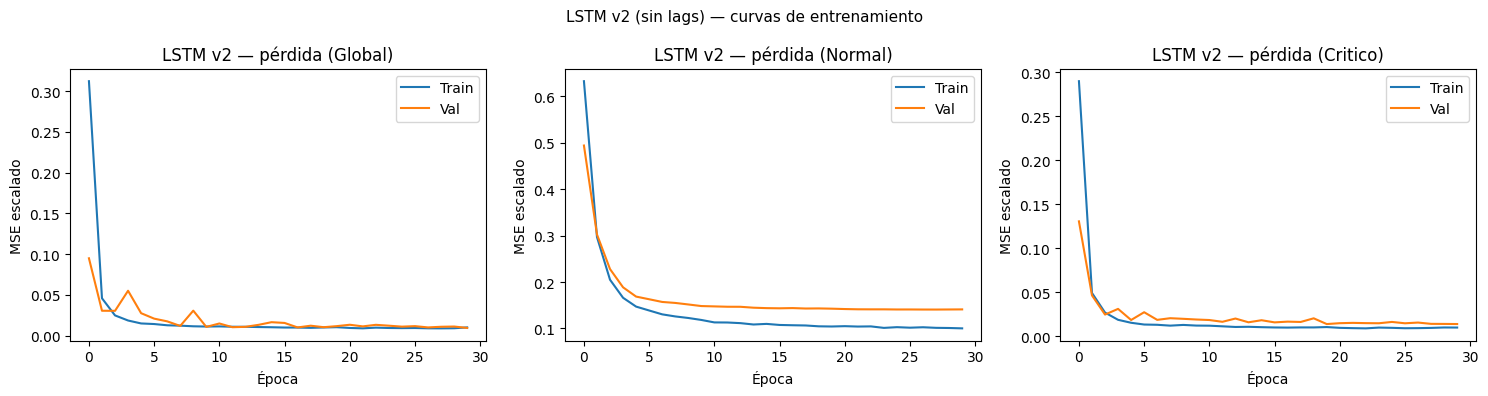

In [ ]:
# ── Curvas de pérdida — LSTM v2 ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (seg_name, history) in zip(axes, lstm_histories_v2.items()):
    ax.plot(history.history['loss'],     label='Train')
    ax.plot(history.history['val_loss'], label='Val')
    ax.set_title(f'LSTM v2 — pérdida ({seg_name})')
    ax.set_xlabel('Época'); ax.set_ylabel('MSE escalado'); ax.legend()
plt.suptitle('LSTM v2 (sin lags) — curvas de entrenamiento', fontsize=11)
plt.tight_layout(); plt.show()

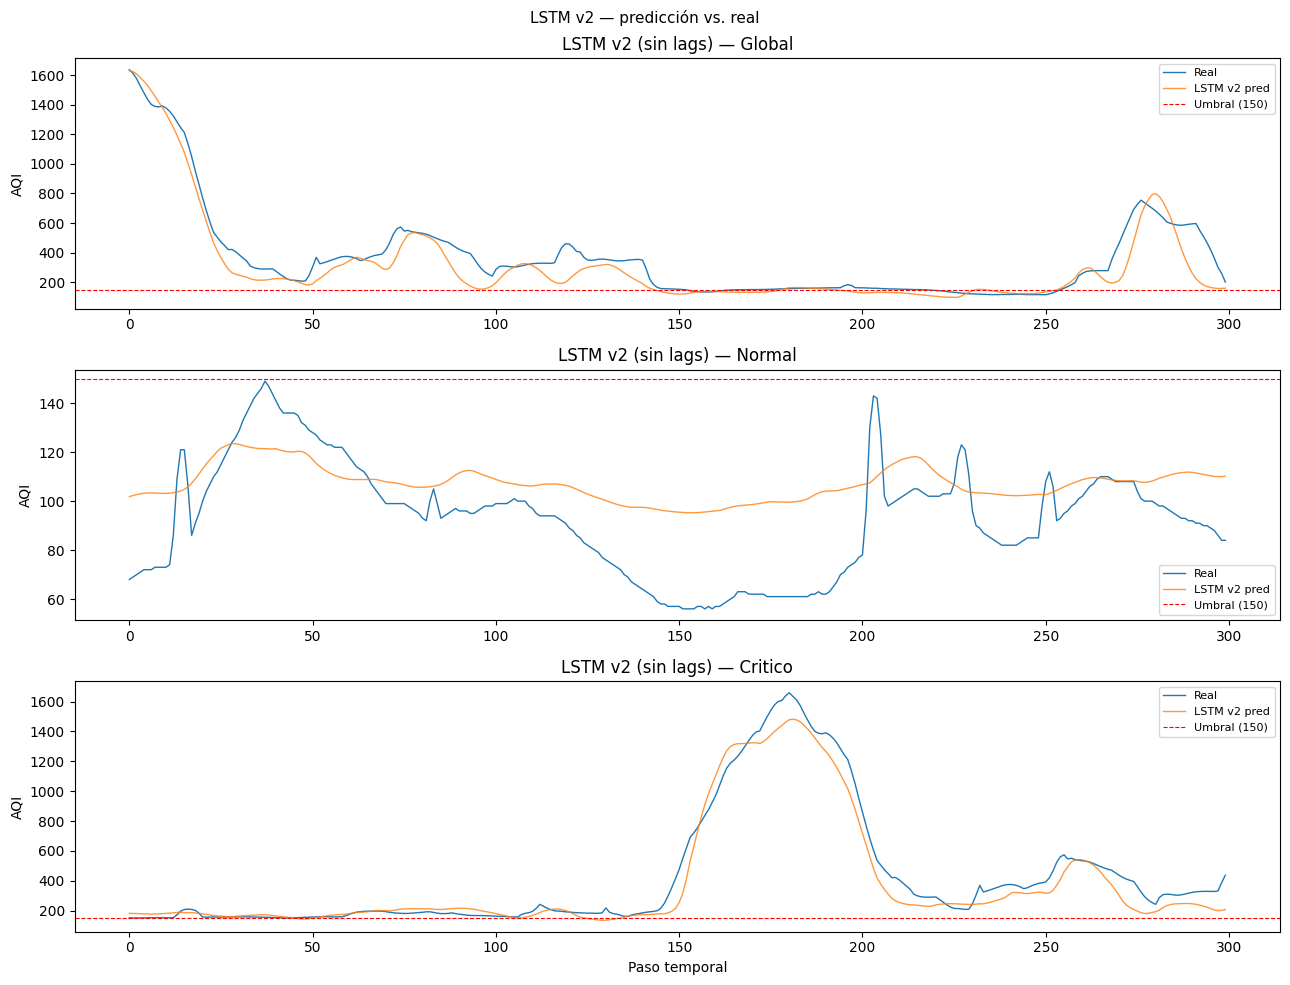

In [ ]:
# ── Predicción vs. real — LSTM v2 ────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 10))
N_PLOT = 300
for ax, (seg_name, (y_real, y_pred)) in zip(axes, lstm_preds_v2.items()):
    ax.plot(y_real[:N_PLOT], label='Real',         linewidth=1)
    ax.plot(y_pred[:N_PLOT], label='LSTM v2 pred', linewidth=1, alpha=0.8)
    ax.axhline(REGIME_THRESHOLD, color='red', linestyle='--',
               linewidth=0.8, label=f'Umbral ({REGIME_THRESHOLD})')
    ax.set_title(f'LSTM v2 (sin lags) — {seg_name}')
    ax.set_ylabel('AQI'); ax.legend(fontsize=8)
axes[-1].set_xlabel('Paso temporal')
plt.suptitle('LSTM v2 — predicción vs. real', fontsize=11)
plt.tight_layout(); plt.show()

## 11. Comparación final y validación de hipótesis

Unificamos clásicos + LSTM v1 + LSTM v2 y validamos las cinco hipótesis.

In [ ]:
# ── Tabla maestra: clásicos + LSTM ───────────────────────────────────────────
df_lstm_v1 = pd.DataFrame(results_lstm_v1)
df_lstm_v2 = pd.DataFrame(results_lstm_v2)
df_todos   = pd.concat([df_reg, df_lstm_v1, df_lstm_v2], ignore_index=True)

print('══ Tabla maestra — Regresión (clásicos + LSTM v1 + LSTM v2) ══')
display(
    df_todos[['segmento','algoritmo','RMSE','MAE','R2']]
    .sort_values(['segmento','RMSE'])
    .reset_index(drop=True)
)

══ Tabla maestra — Regresión (clásicos + LSTM v1 + LSTM v2) ══


,segmento,algoritmo,RMSE,MAE,R2
0,Critico,RegLineal,8.845567,4.853068,0.999406
1,Critico,RF,10.935288,4.884416,0.999092
2,Critico,XGB,12.256988,5.458771,0.998859
3,Critico,LSTM_v1,41.383421,25.030630,0.934871
4,Critico,LSTM_v2,46.748204,28.776035,0.916891
5,Critico,DNN,155.685819,127.437683,0.815943
6,Global,RegLineal,7.121176,3.978162,0.999508
7,Global,RF,9.095624,3.932612,0.999197
8,Global,XGB,11.454206,4.790008,0.998726
9,Global,LSTM_v1,12.731932,8.046505,0.987626


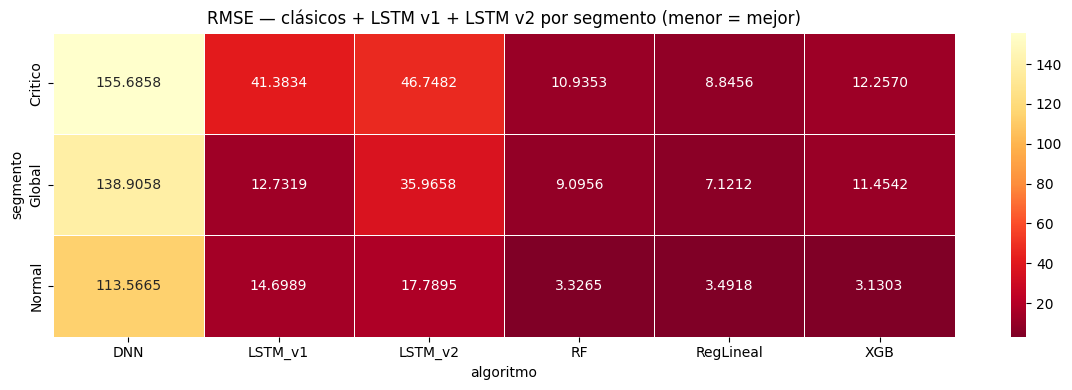

In [ ]:
# Heatmap RMSE completo
pivot_todos = df_todos.pivot_table(
    index='segmento', columns='algoritmo', values='RMSE').round(4)
plt.figure(figsize=(12, 4))
sns.heatmap(pivot_todos, annot=True, fmt='.4f', cmap='YlOrRd_r', linewidths=0.5)
plt.title('RMSE — clásicos + LSTM v1 + LSTM v2 por segmento (menor = mejor)')
plt.tight_layout()
plt.show()

══ Mejor modelo (menor RMSE) por segmento ══

  Global     → RegLineal       RMSE=7.1212  MAE=3.9782  R²=0.9995
  Normal     → XGB             RMSE=3.1303  MAE=1.5757  R²=0.9790
  Critico    → RegLineal       RMSE=8.8456  MAE=4.8531  R²=0.9994


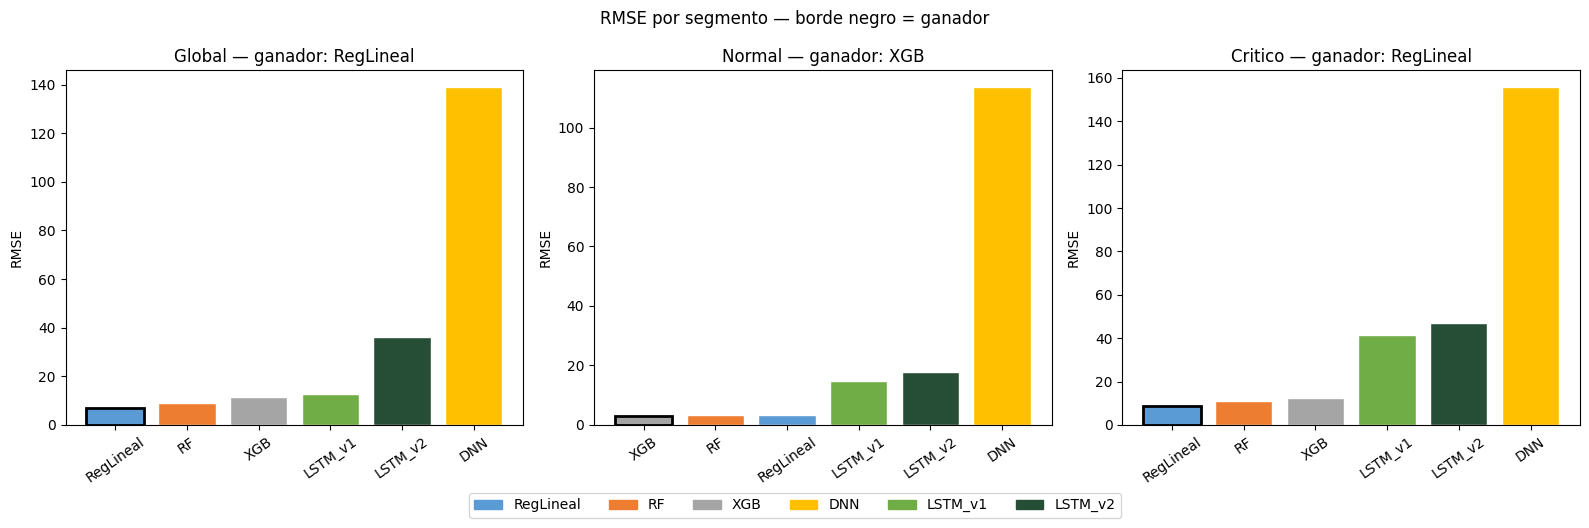

In [ ]:
# Mejor modelo por segmento
print('══ Mejor modelo (menor RMSE) por segmento ══\n')
best_per_seg = {}
for seg in ['Global','Normal','Critico']:
    df_s = df_todos[df_todos['segmento']==seg].sort_values('RMSE')
    best = df_s.iloc[0]
    best_per_seg[seg] = best
    print(f'  {seg:<10} → {best["algoritmo"]:<14}  '
          f'RMSE={best["RMSE"]:.4f}  MAE={best["MAE"]:.4f}  R²={best["R2"]:.4f}')

# Gráfico de barras por segmento
colors_algo = {'RegLineal':'#5B9BD5','RF':'#ED7D31','XGB':'#A5A5A5',
               'DNN':'#FFC000','LSTM_v1':'#70AD47','LSTM_v2':'#264E36'}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, seg in zip(axes, ['Global','Normal','Critico']):
    df_s = df_todos[df_todos['segmento']==seg].sort_values('RMSE')
    bar_c = [colors_algo.get(a,'gray') for a in df_s['algoritmo']]
    bars  = ax.bar(df_s['algoritmo'], df_s['RMSE'], color=bar_c, edgecolor='white')
    bars[0].set_edgecolor('black'); bars[0].set_linewidth(2)
    ax.set_title(f'{seg} — ganador: {df_s.iloc[0]["algoritmo"]}')
    ax.set_ylabel('RMSE'); ax.tick_params(axis='x', rotation=35)

# Leyenda
handles = [mpatches.Patch(color=v, label=k) for k,v in colors_algo.items()]
fig.legend(handles=handles, loc='lower center', ncol=6, bbox_to_anchor=(0.5,-0.05))
plt.suptitle('RMSE por segmento — borde negro = ganador', fontsize=12)
plt.tight_layout(); plt.show()

In [ ]:
# ── H1: ¿modelos por régimen superan al global? ──────────────────────────────
print('══ H1 — Modelos por régimen vs. modelo global ══\n')
rmse_global_best = best_per_seg['Global']['RMSE']
algo_global_best = best_per_seg['Global']['algoritmo']

h1_any = False
for seg in ['Normal','Critico']:
    rmse_s   = best_per_seg[seg]['RMSE']
    algo_s   = best_per_seg[seg]['algoritmo']
    diff_pct = (rmse_s - rmse_global_best) / rmse_global_best * 100
    confirmed = rmse_s < rmse_global_best
    if confirmed: h1_any = True
    print(f'  {seg:<10}: {algo_s:<14} RMSE={rmse_s:.4f}  '
          f'vs Global ({algo_global_best}) RMSE={rmse_global_best:.4f}  '
          f'→ {diff_pct:+.1f}%  {"✓" if confirmed else "✗"}')

print(f'\n  H1: {"CONFIRMADA ✓" if h1_any else "NO CONFIRMADA ✗"}')

══ H1 — Modelos por régimen vs. modelo global ══

  Normal    : XGB            RMSE=3.1303  vs Global (RegLineal) RMSE=7.1212  → -56.0%  ✓
  Critico   : RegLineal      RMSE=8.8456  vs Global (RegLineal) RMSE=7.1212  → +24.2%  ✗

  H1: CONFIRMADA ✓


In [ ]:
# ── H2a/H2b: ¿LSTM v1/v2 supera a los clásicos por segmento? ────────────────
print('══ H2 — LSTM vs. mejor modelo clásico por segmento ══\n')
h2a_results = {}; h2b_results = {}

for seg in ['Global','Normal','Critico']:
    df_s      = df_todos[df_todos['segmento']==seg]
    df_cls    = df_s[~df_s['algoritmo'].isin(['LSTM_v1','LSTM_v2'])].sort_values('RMSE')
    best_cls  = df_cls.iloc[0]

    rmse_v1 = df_s[df_s['algoritmo']=='LSTM_v1']['RMSE'].values
    rmse_v2 = df_s[df_s['algoritmo']=='LSTM_v2']['RMSE'].values

    print(f'  {seg} — mejor clásico: {best_cls["algoritmo"]} RMSE={best_cls["RMSE"]:.4f}')
    if len(rmse_v1):
        d = (rmse_v1[0] - best_cls['RMSE']) / best_cls['RMSE'] * 100
        c = rmse_v1[0] < best_cls['RMSE']
        h2a_results[seg] = c
        print(f'    LSTM v1: RMSE={rmse_v1[0]:.4f}  → {d:+.1f}%  {"✓" if c else "✗"}')
    if len(rmse_v2):
        d = (rmse_v2[0] - best_cls['RMSE']) / best_cls['RMSE'] * 100
        c = rmse_v2[0] < best_cls['RMSE']
        h2b_results[seg] = c
        print(f'    LSTM v2: RMSE={rmse_v2[0]:.4f}  → {d:+.1f}%  {"✓" if c else "✗"}')
    print()

print(f'  H2a (LSTM v1 con lags): Global={"✓" if h2a_results.get("Global") else "✗"}  '
      f'Normal={"✓" if h2a_results.get("Normal") else "✗"}  '
      f'Crítico={"✓" if h2a_results.get("Critico") else "✗"}')
print(f'  H2b (LSTM v2 sin lags): Global={"✓" if h2b_results.get("Global") else "✗"}  '
      f'Normal={"✓" if h2b_results.get("Normal") else "✗"}  '
      f'Crítico={"✓" if h2b_results.get("Critico") else "✗"}')

══ H2 — LSTM vs. mejor modelo clásico por segmento ══

  Global — mejor clásico: RegLineal RMSE=7.1212
    LSTM v1: RMSE=12.7319  → +78.8%  ✗
    LSTM v2: RMSE=35.9658  → +405.1%  ✗

  Normal — mejor clásico: XGB RMSE=3.1303
    LSTM v1: RMSE=14.6989  → +369.6%  ✗
    LSTM v2: RMSE=17.7895  → +468.3%  ✗

  Critico — mejor clásico: RegLineal RMSE=8.8456
    LSTM v1: RMSE=41.3834  → +367.8%  ✗
    LSTM v2: RMSE=46.7482  → +428.5%  ✗

  H2a (LSTM v1 con lags): Global=✗  Normal=✗  Crítico=✗
  H2b (LSTM v2 sin lags): Global=✗  Normal=✗  Crítico=✗


In [ ]:
# ── H3: ¿LSTM v1 supera a LSTM v2? ──────────────────────────────────────────
print('══ H3 — LSTM v1 (con lags) vs. LSTM v2 (sin lags) ══\n')
h3_results = {}
for seg in ['Global','Normal','Critico']:
    df_s   = df_todos[df_todos['segmento']==seg]
    rv1    = df_s[df_s['algoritmo']=='LSTM_v1']['RMSE'].values
    rv2    = df_s[df_s['algoritmo']=='LSTM_v2']['RMSE'].values
    if len(rv1) and len(rv2):
        d = (rv1[0] - rv2[0]) / rv2[0] * 100
        winner = 'LSTM v1' if rv1[0] < rv2[0] else 'LSTM v2'
        h3_results[seg] = rv1[0] < rv2[0]
        print(f'  {seg:<10}: v1={rv1[0]:.4f}  v2={rv2[0]:.4f}  '
              f'diff={d:+.1f}%  ganador={winner}')

h3_v1_wins = sum(h3_results.values())
print(f'\n  H3: LSTM v1 gana en {h3_v1_wins}/3 segmentos  '
      f'{"→ lags mejoran el LSTM ✓" if h3_v1_wins > 1 else "→ lags no mejoran el LSTM ✗"}')

══ H3 — LSTM v1 (con lags) vs. LSTM v2 (sin lags) ══

  Global    : v1=12.7319  v2=35.9658  diff=-64.6%  ganador=LSTM v1
  Normal    : v1=14.6989  v2=17.7895  diff=-17.4%  ganador=LSTM v1
  Critico   : v1=41.3834  v2=46.7482  diff=-11.5%  ganador=LSTM v1

  H3: LSTM v1 gana en 3/3 segmentos  → lags mejoran el LSTM ✓


In [ ]:
# ── H4: ¿LSTM se comporta distinto entre regímenes? ─────────────────────────
print('══ H4 — Variación del LSTM entre regímenes ══\n')
for version, df_v in [('LSTM v1', df_lstm_v1), ('LSTM v2', df_lstm_v2)]:
    df_v_idx = df_v.set_index('segmento')
    rn = df_v_idx.loc['Normal',  'RMSE'] if 'Normal'  in df_v_idx.index else np.nan
    rc = df_v_idx.loc['Critico', 'RMSE'] if 'Critico' in df_v_idx.index else np.nan
    if not np.isnan(rn) and not np.isnan(rc):
        diff = (rc - rn) / rn * 100
        print(f'  {version}: Normal RMSE={rn:.4f}  Crítico RMSE={rc:.4f}  '
              f'diff={diff:+.1f}%  {"✓ distinto" if abs(diff)>10 else "~ similar"}')

print()
print('  H4: confirmada si al menos una versión muestra diferencia > 10% entre regímenes')

══ H4 — Variación del LSTM entre regímenes ══

  LSTM v1: Normal RMSE=14.6989  Crítico RMSE=41.3834  diff=+181.5%  ✓ distinto
  LSTM v2: Normal RMSE=17.7895  Crítico RMSE=46.7482  diff=+162.8%  ✓ distinto

  H4: confirmada si al menos una versión muestra diferencia > 10% entre regímenes


In [ ]:
# ── Tabla clasificación — mejor por segmento ─────────────────────────────────
print('══ Clasificación — mejor F1 por segmento ══\n')
for seg in ['Global','Normal','Critico']:
    df_s = df_clf[df_clf['segmento']==seg].sort_values('f1_weighted', ascending=False)
    best = df_s.iloc[0]
    print(f'  {seg:<10} → {best["algoritmo"]:<10}  '
          f'F1={best["f1_weighted"]:.4f}  Acc={best["accuracy"]:.4f}  AUC={best["auc_roc"]:.4f}')

══ Clasificación — mejor F1 por segmento ══

  Global     → XGB         F1=0.9757  Acc=0.9757  AUC=0.9987
  Normal     → XGB         F1=0.9862  Acc=0.9863  AUC=0.9990
  Critico    → RF          F1=0.9822  Acc=0.9822  AUC=0.9991


In [ ]:
# ── Resumen ejecutivo final ───────────────────────────────────────────────────
print('══════════════════════════════════════════════════════════════════')
print('  RESUMEN EJECUTIVO — PROYECTO AQI DELHI')
print('══════════════════════════════════════════════════════════════════')

print('\n── Decisiones metodológicas ─────────────────────────────────────')
print(f'  6 estaciones → 2 grupos duplicados → 1 estación por grupo')
print(f'  Estaciones: {REP_A} (Grupo A) y {REP_B} (Grupo B)')
print(f'  Segmentación: régimen normal (AQI ≤ {REGIME_THRESHOLD}) vs. crítico')

print('\n── Mejor modelo por segmento (regresión) ────────────────────────')
for seg in ['Global','Normal','Critico']:
    b = best_per_seg[seg]
    print(f'  {seg:<10}: {b["algoritmo"]:<14} RMSE={b["RMSE"]:.4f}  R²={b["R2"]:.4f}')

print('\n── Validación de hipótesis ──────────────────────────────────────')
print(f'  H1  (régimen vs. global):           {"CONFIRMADA ✓" if h1_any else "NO CONFIRMADA ✗"}')
print(f'  H2a (LSTM v1 vs. clásicos):         Global={"✓" if h2a_results.get("Global") else "✗"}  Normal={"✓" if h2a_results.get("Normal") else "✗"}  Crítico={"✓" if h2a_results.get("Critico") else "✗"}')
print(f'  H2b (LSTM v2 vs. clásicos):         Global={"✓" if h2b_results.get("Global") else "✗"}  Normal={"✓" if h2b_results.get("Normal") else "✗"}  Crítico={"✓" if h2b_results.get("Critico") else "✗"}')
print(f'  H3  (LSTM v1 vs. LSTM v2):          v1 gana en {h3_v1_wins}/3 segmentos')
print(f'  H4  (LSTM varía entre regímenes):   ver tabla H4 arriba')

print('\n══════════════════════════════════════════════════════════════════')
print('  FIN DEL ANÁLISIS')
print('══════════════════════════════════════════════════════════════════')

══════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — PROYECTO AQI DELHI
══════════════════════════════════════════════════════════════════

── Decisiones metodológicas ─────────────────────────────────────
  6 estaciones → 2 grupos duplicados → 1 estación por grupo
  Estaciones: Anand Vihar (Grupo A) y Dwarka (Grupo B)
  Segmentación: régimen normal (AQI ≤ 150) vs. crítico

── Mejor modelo por segmento (regresión) ────────────────────────
  Global    : RegLineal      RMSE=7.1212  R²=0.9995
  Normal    : XGB            RMSE=3.1303  R²=0.9790
  Critico   : RegLineal      RMSE=8.8456  R²=0.9994

── Validación de hipótesis ──────────────────────────────────────
  H1  (régimen vs. global):           CONFIRMADA ✓
  H2a (LSTM v1 vs. clásicos):         Global=✗  Normal=✗  Crítico=✗
  H2b (LSTM v2 vs. clásicos):         Global=✗  Normal=✗  Crítico=✗
  H3  (LSTM v1 vs. LSTM v2):          v1 gana en 3/3 segmentos
  H4  (LSTM varía entre regímenes):   ver tabla 